# Comparative Visualization of Fine-Tuned CNN Models for Brain Tumor MRI Classification

### VGG16 vs DenseNet121 vs EfficientNet vs ResNet50 vs MobileNetV3Large

This notebook analyzes the dataset, fine-tuning configuration, model complexity, training behavior, and classification performance of five ImageNet-pretrained convolutional neural networks used for four-class brain tumor MRI classification.

The class order recovered from all five saved training-notebook outputs is **glioma, meningioma, notumor, pituitary**. The live dataset is rediscovered below and must confirm this order before a fair comparison is made.

## Research Objective

The objective is to determine which fine-tuned architecture gives the best balance between:

- classification performance
- generalization
- model complexity
- computational efficiency

No model is declared best until comparable metrics have been calculated from aligned held-out predictions.

## 0. Setup and Project Discovery

In [31]:
import os
import re
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# TensorFlow 2.x calls this protobuf compatibility method; protobuf 5+ removed it.
try:
    from google.protobuf import message_factory
    if not hasattr(message_factory.MessageFactory, "GetPrototype"):
        message_factory.MessageFactory.GetPrototype = lambda self, descriptor: message_factory.GetMessageClass(descriptor)
except Exception:
    pass

try:
    import tensorflow as tf
    from tensorflow.keras.models import load_model
    TF_AVAILABLE = True
except Exception as exc:
    tf, load_model, TF_AVAILABLE = None, None, False
    print(f"TensorFlow unavailable; model inference is disabled: {exc}")

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
np.random.seed(SEED)
if TF_AVAILABLE:
    tf.random.set_seed(SEED)

MODEL_ORDER = ["VGG16", "DenseNet121", "EfficientNet", "ResNet50", "MobileNetV3Large"]
EXPECTED_CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
MODEL_TOKENS = {
    "VGG16": "vgg", "DenseNet121": "dense", "EfficientNet": "efficient",
    "ResNet50": "resnet", "MobileNetV3Large": "mobile"
}
COLORS = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

PROJECT_ROOT = Path.cwd()
# Optional portable overrides: set to a Path if automatic discovery is ambiguous.
DATASET_ROOT = None
TRAIN_DIR = None
TEST_DIR = None
RUN_MODEL_INFERENCE = True  # Set True: dataset + all five .h5/.keras files are present locally.
INFERENCE_BATCH_SIZE = 32

OUTPUT_DIR = PROJECT_ROOT / "visualization_outputs"
CACHE_DIR = PROJECT_ROOT / "visualization_cache"

def save_figure(filename):
    """Save the current report-ready figure without changing existing artifacts."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")

def show_unavailable(message="Not available from saved experiment"):
    """Display a consistent missing-artifact message."""
    print(message)

def _all_files(root):
    """Return all project files while avoiding generated output/cache trees."""
    blocked = {"visualization_outputs", "visualization_cache", ".git", ".ipynb_checkpoints"}
    return [p for p in root.rglob("*") if p.is_file() and not blocked.intersection(p.parts)]

In [32]:
def discover_project_files(root=PROJECT_ROOT):
    """Discover notebooks, datasets, models, histories, reports and prediction artifacts."""
    files = _all_files(root)
    notebooks = [p for p in files if p.suffix.lower() == ".ipynb" and p.name != "data_model_visualization.ipynb"]
    found_notebooks = {}
    for model, token in MODEL_TOKENS.items():
        matches = [p for p in notebooks if token in p.name.lower()]
        found_notebooks[model] = sorted(matches, key=lambda p: (len(p.name), p.name))[0] if matches else None
    groups = {
        "notebooks": found_notebooks,
        "models": [p for p in files if p.suffix.lower() in {".h5", ".keras"}],
        "json": [p for p in files if p.suffix.lower() == ".json"],
        "csv": [p for p in files if p.suffix.lower() == ".csv"],
        "numpy": [p for p in files if p.suffix.lower() in {".npy", ".npz"}],
    }
    return groups

def find_dataset(root=PROJECT_ROOT):
    """Find directories containing train/test class-folder structures."""
    dirs = [p for p in root.rglob("*") if p.is_dir()]
    train_names, test_names = {"training", "train"}, {"testing", "test"}
    trains = [p for p in dirs if p.name.lower() in train_names]
    tests = [p for p in dirs if p.name.lower() in test_names]
    pairs = []
    for tr in trains:
        for te in tests:
            if tr.parent == te.parent:
                tr_classes = sorted(x.name for x in tr.iterdir() if x.is_dir())
                te_classes = sorted(x.name for x in te.iterdir() if x.is_dir())
                if tr_classes and tr_classes == te_classes:
                    pairs.append((tr.parent, tr, te, tr_classes))
    return pairs

artifacts = discover_project_files()
dataset_candidates = find_dataset()
print("Project root:", PROJECT_ROOT)
print("\nTraining notebooks:")
for model, path in artifacts["notebooks"].items():
    print(f"  {model}: {path if path else 'Not available from saved experiment'}")
print("\nSaved model files:", [str(p) for p in artifacts["models"]] or "None discovered")
print("JSON files:", [str(p) for p in artifacts["json"]] or "None discovered")
print("CSV files:", [str(p) for p in artifacts["csv"]] or "None discovered")
print("Prediction/history arrays:", [str(p) for p in artifacts["numpy"]] or "None discovered")
print("Dataset candidates:", [(str(a), str(b), str(c), d) for a,b,c,d in dataset_candidates] or "None discovered")

if DATASET_ROOT is None and dataset_candidates:
    DATASET_ROOT, AUTO_TRAIN, AUTO_TEST, _ = dataset_candidates[0]
    TRAIN_DIR = TRAIN_DIR or AUTO_TRAIN
    TEST_DIR = TEST_DIR or AUTO_TEST
elif DATASET_ROOT is not None:
    DATASET_ROOT = Path(DATASET_ROOT)
    TRAIN_DIR = Path(TRAIN_DIR) if TRAIN_DIR else next((p for p in DATASET_ROOT.iterdir() if p.name.lower() in {"training","train"}), None)
    TEST_DIR = Path(TEST_DIR) if TEST_DIR else next((p for p in DATASET_ROOT.iterdir() if p.name.lower() in {"testing","test"}), None)

Project root: d:\Project-sem2

Training notebooks:
  VGG16: d:\Project-sem2\brain_tumor_classification_vgg16.ipynb
  DenseNet121: d:\Project-sem2\brain_tumor_classification_densenet121.ipynb
  EfficientNet: d:\Project-sem2\brain_tumor_classification_efficientnet.ipynb
  ResNet50: d:\Project-sem2\brain_tumor_classification_resnet50.ipynb
  MobileNetV3Large: d:\Project-sem2\brain_tumor_classification_mobilenetv3large.ipynb

Saved model files: ['d:\\Project-sem2\\model_densenet121.h5', 'd:\\Project-sem2\\model_efficientnet.h5', 'd:\\Project-sem2\\model_mobilenetv3large.keras', 'd:\\Project-sem2\\model_resnet50.h5', 'd:\\Project-sem2\\model_vgg16_v2.h5']
JSON files: ['d:\\Project-sem2\\class_labels.json']
CSV files: ['d:\\Project-sem2\\visualization_outputs1\\augmentation_audit.csv', 'd:\\Project-sem2\\visualization_outputs1\\dataset_distribution.csv', 'd:\\Project-sem2\\visualization_outputs1\\model_configurations.csv', 'd:\\Project-sem2\\visualization_outputs1\\model_parameters.csv', 'd:

The cells below parse the original notebooks rather than copying assumed values. ANSI formatting in saved outputs is removed before extracting summaries and histories. Metrics recovered only from rounded classification-report text are explicitly marked as reported metrics; they are not substituted for probability-based, path-aligned evaluation.

In [33]:
ANSI_RE = re.compile(r"\x1b\[[0-?]*[ -/]*[@-~]")

def notebook_text(path):
    """Return source text and plain-text outputs from a notebook."""
    with open(path, encoding="utf-8") as f:
        doc = json.load(f)
    source = "\n".join("".join(c.get("source", [])) for c in doc.get("cells", []))
    outputs = []
    for cell in doc.get("cells", []):
        for out in cell.get("outputs", []):
            outputs.append("".join(out.get("text", [])))
            outputs.append("".join(out.get("data", {}).get("text/plain", [])))
    return source, ANSI_RE.sub("", "\n".join(outputs)), doc

def first_match(pattern, text, cast=None, default=np.nan):
    """Return the first regex capture, optionally cast, or a missing value."""
    match = re.search(pattern, text, flags=re.I | re.S)
    if not match:
        return default
    value = match.group(1).strip()
    try:
        return cast(value) if cast else value
    except Exception:
        return default

def parse_training_notebook(model_name, path):
    """Extract verified configuration and final fine-tuning summary values."""
    source, output, doc = notebook_text(path)
    param_rows = re.findall(
        r"Total params:\s*([\d,]+).*?Trainable params:\s*([\d,]+).*?Non-trainable params:\s*([\d,]+)",
        output, flags=re.S
    )
    final_params = param_rows[-1] if param_rows else (None, None, None)
    backbone = first_match(r"base_model\s*=\s*([A-Za-z0-9_]+)\s*\(", source)
    preprocessing = first_match(r"from\s+tensorflow\.keras\.applications\.[^\s]+\s+import\s+(preprocess_input)", source)
    optimizer = first_match(r"optimizer\s*=\s*([A-Za-z0-9_]+)\s*\(", source)
    lrs = re.findall(r"optimizer\s*=\s*[A-Za-z0-9_]+\s*\(\s*learning_rate\s*=\s*([0-9.eE+-]+)", source)
    phase1 = first_match(r"epochs_phase1\s*=\s*(\d+)", source, int)
    phase2 = first_match(r"epochs_phase2\s*=\s*(\d+)", source, int)
    epoch_lines = re.findall(r"Epoch\s+\d+/\d+", output)
    class_match = re.search(r"Class label order \(fixed\):\s*\[([^\]]+)\]", output)
    classes = [x.strip(" '\"") for x in class_match.group(1).split(",")] if class_match else []
    callbacks = {
        "early": first_match(r"EarlyStopping\((.*?)\)", source),
        "reduce": first_match(r"ReduceLROnPlateau\((.*?)\)", source)
    }
    fine_expr = first_match(r"fine_tune_at\s*=\s*([^\n#]+)", source)
    unfrozen = first_match(r"fine_tune_at\s*=\s*len\(base_model\.layers\)\s*-\s*(\d+)", source, int)
    saved = first_match(r"model\.save\(['\"]([^'\"]+)", source)
    return {
        "Model": model_name, "Backbone": backbone, "Input Size": first_match(r"IMAGE_SIZE\s*=\s*(\d+)", source, int),
        "Classes": len(classes) if classes else np.nan, "Class Labels": ", ".join(classes) if classes else "Not available from saved experiment",
        "Batch Size": first_match(r"batch_size\s*=\s*(\d+)", source, int),
        "Phase 1 Epochs": phase1, "Phase 2 Max Epochs": phase2, "Actual Epochs": len(epoch_lines),
        "Fine-Tuning Start Epoch": phase1 + 1 if not pd.isna(phase1) else np.nan,
        "Phase 1 LR": float(lrs[0]) if lrs else np.nan, "Fine-Tune LR": float(lrs[-1]) if len(lrs) > 1 else np.nan,
        "Optimizer": optimizer, "Loss": first_match(r"loss\s*=\s*['\"]([^'\"]+)", source),
        "Fine-Tuned Layers": f"Last {unfrozen} backbone layers considered; BatchNorm frozen where coded" if not pd.isna(unfrozen) else fine_expr,
        "Unfrozen Layer Window": unfrozen, "Early Stopping": callbacks["early"], "LR Scheduler": callbacks["reduce"],
        "Preprocessing": preprocessing or "Not available from saved experiment", "Saved Model Reference": saved,
        "Total Parameters": int(final_params[0].replace(",","")) if final_params[0] else np.nan,
        "Trainable Parameters": int(final_params[1].replace(",","")) if final_params[1] else np.nan,
        "Non-Trainable Parameters": int(final_params[2].replace(",","")) if final_params[2] else np.nan,
        "_source": source, "_output": output, "_doc": doc
    }

parsed = {}
for model in MODEL_ORDER:
    path = artifacts["notebooks"].get(model)
    if path:
        parsed[model] = parse_training_notebook(model, path)

visible_columns = [
    "Model","Backbone","Input Size","Classes","Class Labels","Batch Size","Phase 1 Epochs",
    "Phase 2 Max Epochs","Actual Epochs","Fine-Tuning Start Epoch","Phase 1 LR","Fine-Tune LR",
    "Optimizer","Loss","Fine-Tuned Layers","Early Stopping","LR Scheduler","Preprocessing"
]
model_config_df = pd.DataFrame([{k:v for k,v in row.items() if not k.startswith("_")} for row in parsed.values()])
model_config_df = model_config_df.set_index("Model").reindex(MODEL_ORDER).reset_index()
display(model_config_df[visible_columns].fillna("Not available from saved experiment"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model_config_df.to_csv(OUTPUT_DIR / "model_configurations.csv", index=False)

,Model,Backbone,Input Size,Classes,Class Labels,Batch Size,Phase 1 Epochs,Phase 2 Max Epochs,Actual Epochs,Fine-Tuning Start Epoch,Phase 1 LR,Fine-Tune LR,Optimizer,Loss,Fine-Tuned Layers,Early Stopping,LR Scheduler,Preprocessing
0,VGG16,VGG16,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 4 backbone layers considered; BatchNorm f...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
1,DenseNet121,DenseNet121,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 40 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
2,EfficientNet,EfficientNetB0,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 30 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
3,ResNet50,ResNet50,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 20 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
4,MobileNetV3Large,MobileNetV3Large,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 20 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input


## 1. Dataset Exploration
### Dataset Summary
### Class Distribution
### Train/Test Distribution

,Class,Training,Testing,Total,Train Percentage,Test Percentage
0,glioma,1400,400,1800,77.777778,22.222222
1,meningioma,1400,400,1800,77.777778,22.222222
2,notumor,1400,400,1800,77.777778,22.222222
3,pituitary,1400,400,1800,77.777778,22.222222


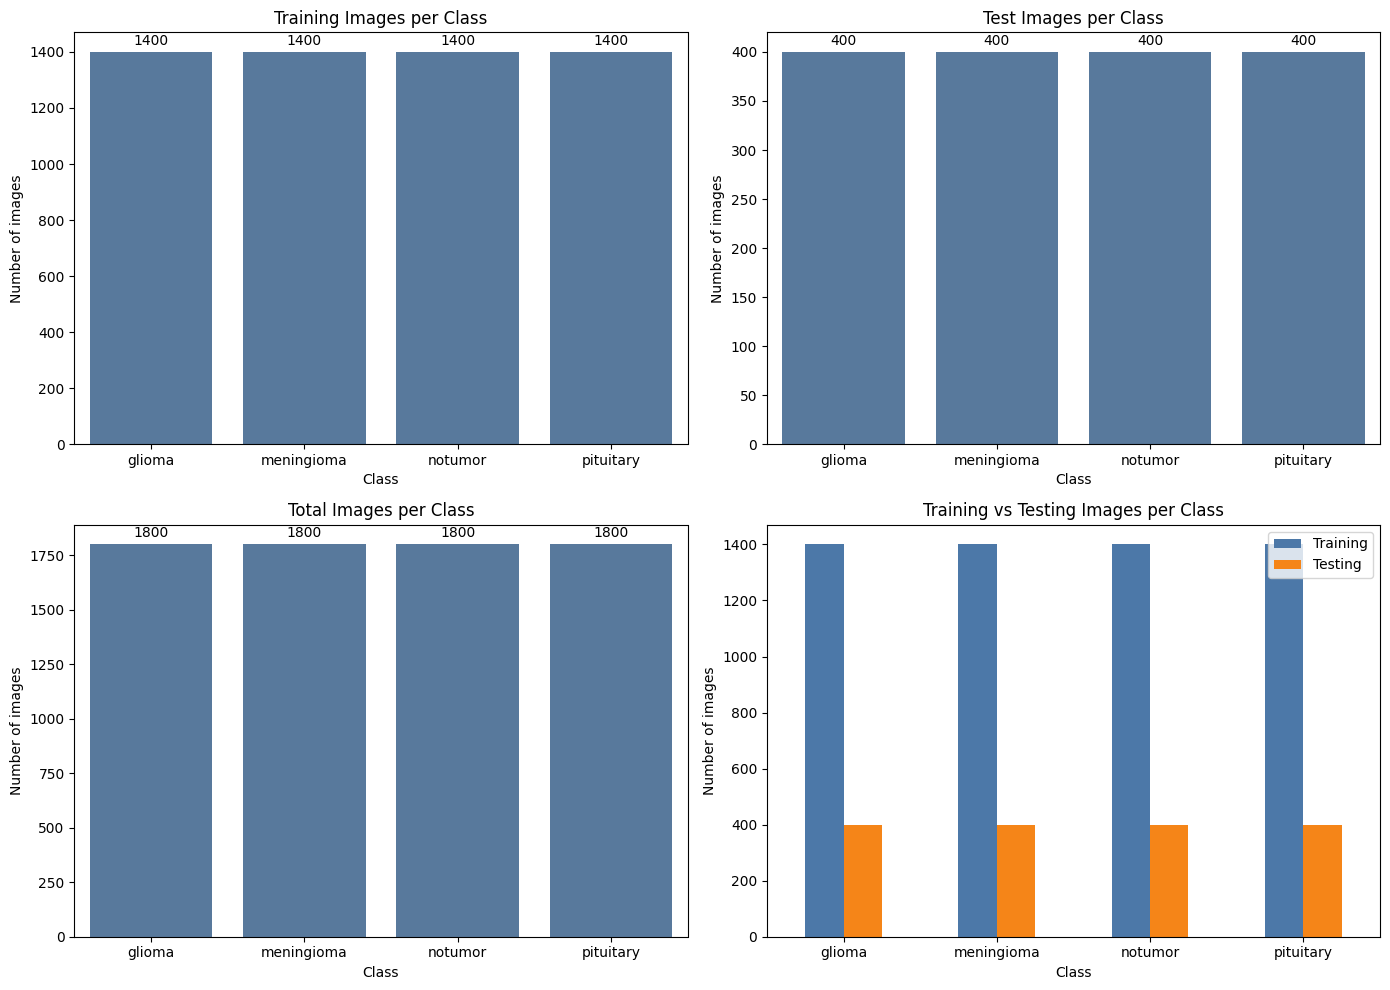

Class imbalance ratio (maximum/minimum total count): 1.000
A ratio near 1 indicates approximate numerical balance; this is a dataset description, not a medical claim.
          Percentage
Training   77.777778
Testing    22.222222


In [34]:
def image_paths_by_class(directory):
    """Return a stable class-to-image-path mapping."""
    if directory is None or not Path(directory).exists():
        return {}
    return {
        d.name: sorted(p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
        for d in sorted(Path(directory).iterdir()) if d.is_dir()
    }

def get_dataset_distribution(train_dir, test_dir):
    """Count real images by class and split."""
    train_map, test_map = image_paths_by_class(train_dir), image_paths_by_class(test_dir)
    classes = sorted(set(train_map) | set(test_map))
    rows = []
    for cls in classes:
        tr, te = len(train_map.get(cls, [])), len(test_map.get(cls, []))
        total = tr + te
        rows.append({"Class": cls, "Training": tr, "Testing": te, "Total": total,
                     "Train Percentage": 100*tr/total if total else np.nan,
                     "Test Percentage": 100*te/total if total else np.nan})
    return pd.DataFrame(rows), train_map, test_map

dataset_distribution, train_images, test_images = get_dataset_distribution(TRAIN_DIR, TEST_DIR)
if dataset_distribution.empty:
    show_unavailable("Dataset not present under the current project root. Set DATASET_ROOT/TRAIN_DIR/TEST_DIR when available.")
else:
    display(dataset_distribution)
    dataset_distribution.to_csv(OUTPUT_DIR / "dataset_distribution.csv", index=False)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    charts = [
        ("Training", "Training Images per Class"),
        ("Testing", "Test Images per Class"),
        ("Total", "Total Images per Class")
    ]
    for ax, (col, title) in zip(axes.flat[:3], charts):
        sns.barplot(data=dataset_distribution, x="Class", y=col, ax=ax, color="#4C78A8")
        ax.set_title(title); ax.set_ylabel("Number of images")
        for container in ax.containers: ax.bar_label(container, padding=3)
    dataset_distribution.plot(x="Class", y=["Training","Testing"], kind="bar", ax=axes.flat[3],
                              color=["#4C78A8","#F58518"], rot=0)
    axes.flat[3].set_title("Training vs Testing Images per Class"); axes.flat[3].set_ylabel("Number of images")
    save_figure("01_dataset_distribution.png"); plt.show()

    counts = dataset_distribution["Total"]
    ratio = counts.max()/counts.min() if counts.min() else np.inf
    print(f"Class imbalance ratio (maximum/minimum total count): {ratio:.3f}")
    print("A ratio near 1 indicates approximate numerical balance; this is a dataset description, not a medical claim.")
    split = dataset_distribution[["Training","Testing"]].sum()
    print((100*split/split.sum()).rename("Percentage").to_frame())

### Sample MRI Images
### Original Image Dimensions

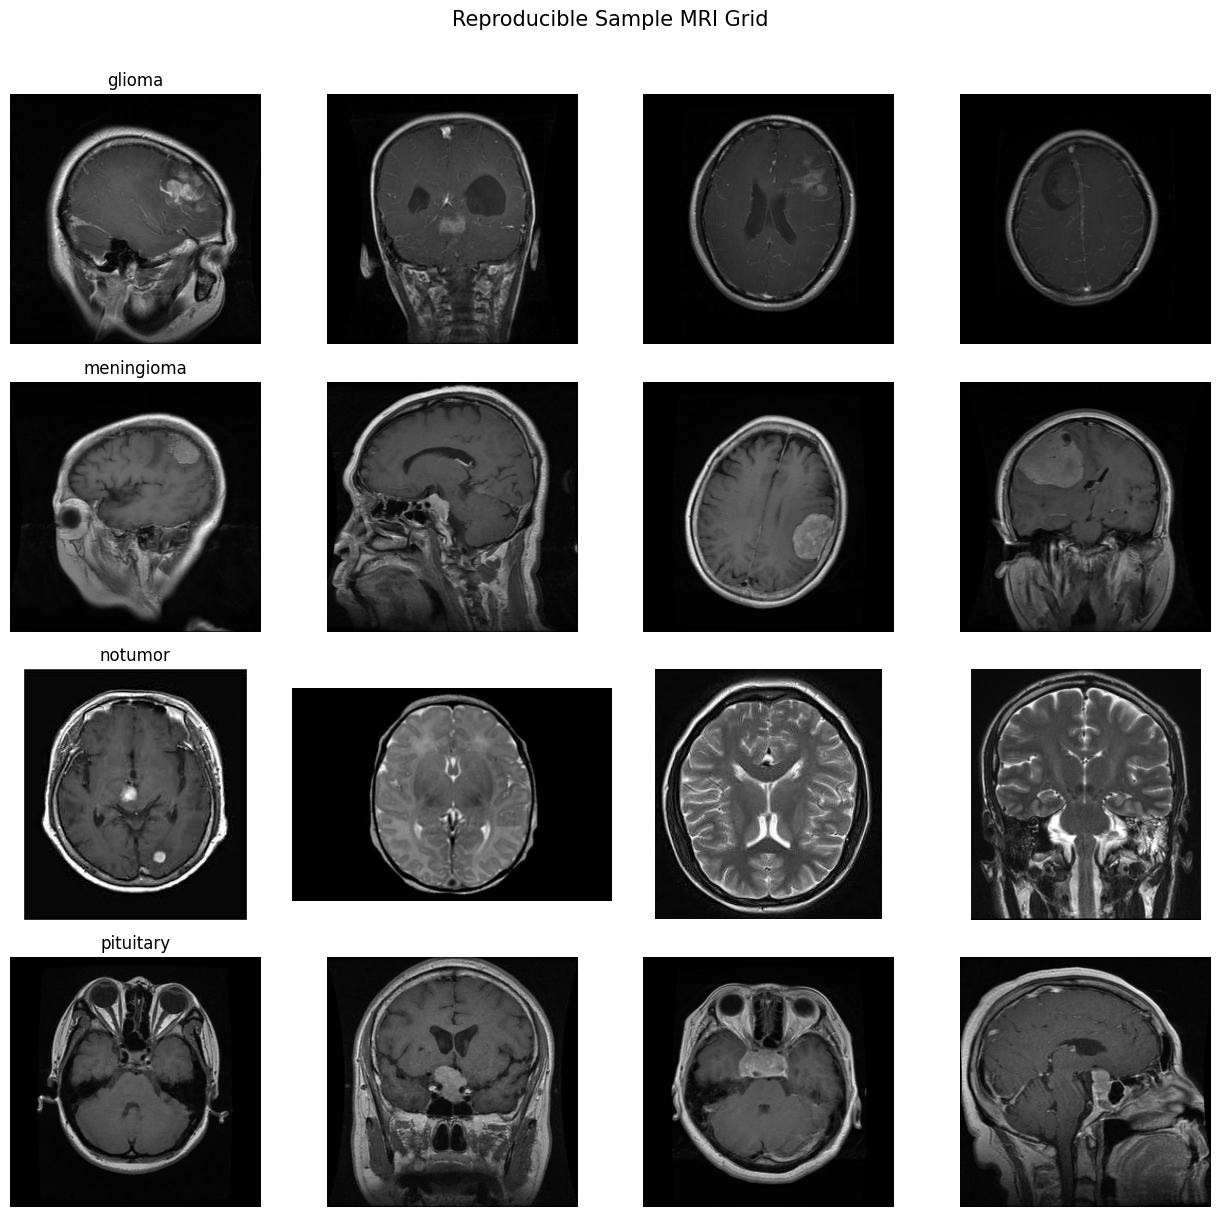

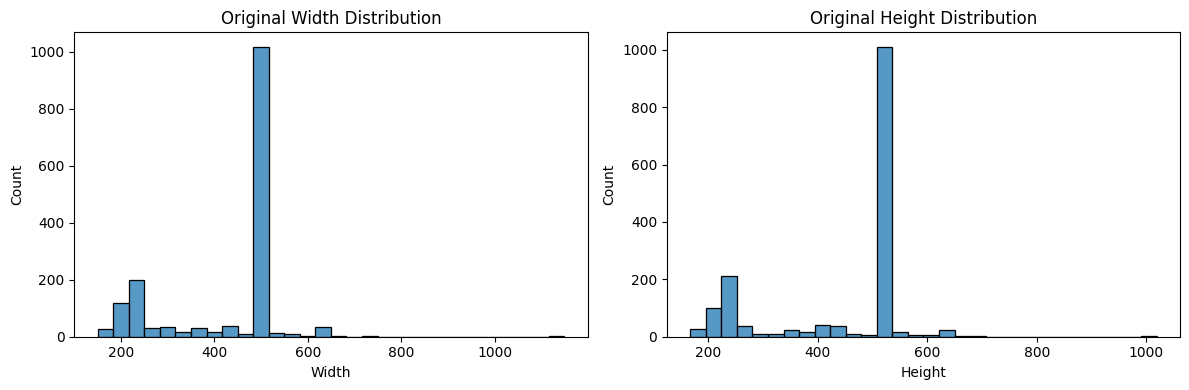

,Width,Height,Count
0,512,512,1002
1,225,225,85
2,630,630,21
3,228,221,19
4,227,222,19
5,232,217,18
6,201,251,17
7,200,252,14
8,300,168,13
9,150,198,11


Model input dimensions (from notebooks):


,Model,Input Size
0,VGG16,224
1,DenseNet121,224
2,EfficientNet,224
3,ResNet50,224
4,MobileNetV3Large,224


In [35]:
def sample_mri_grid(class_map, samples_per_class=4, seed=SEED):
    """Display reproducibly selected real MRI images."""
    if not class_map:
        return show_unavailable("Sample grid unavailable because the dataset is not present.")
    rng = np.random.default_rng(seed)
    classes = sorted(class_map)
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(13, 3*len(classes)), squeeze=False)
    for r, cls in enumerate(classes):
        paths = class_map[cls]
        chosen = rng.choice(paths, size=min(samples_per_class, len(paths)), replace=False) if paths else []
        for c, ax in enumerate(axes[r]):
            ax.axis("off")
            if c < len(chosen):
                with Image.open(chosen[c]) as image:
                    ax.imshow(image.convert("RGB"))
                ax.set_title(cls if c == 0 else "")
    fig.suptitle("Reproducible Sample MRI Grid", y=1.01, fontsize=15)
    save_figure("02_dataset_samples.png"); plt.show()

def get_image_dimensions(class_map):
    """Inspect original image dimensions without resizing."""
    rows = []
    for cls, paths in class_map.items():
        for p in paths:
            try:
                with Image.open(p) as image:
                    rows.append({"Class":cls, "Width":image.width, "Height":image.height, "Path":str(p)})
            except Exception as exc:
                print(f"Skipped unreadable image {p}: {exc}")
    return pd.DataFrame(rows)

sample_mri_grid(train_images)
dimension_df = get_image_dimensions({**train_images, **test_images})
if dimension_df.empty:
    show_unavailable("Original image dimensions are unavailable because dataset images are absent.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(dimension_df["Width"], bins=30, ax=axes[0]); axes[0].set_title("Original Width Distribution")
    sns.histplot(dimension_df["Height"], bins=30, ax=axes[1]); axes[1].set_title("Original Height Distribution")
    plt.tight_layout(); plt.show()
    display(dimension_df.groupby(["Width","Height"]).size().rename("Count").sort_values(ascending=False).head(15).reset_index())
    print("Model input dimensions (from notebooks):")
    display(model_config_df[["Model","Input Size"]])

### Data Augmentation Audit

The five training notebooks are inspected to determine whether augmentation was performed, whether augmented images were saved to disk, and how many augmented samples were processed. The calculation uses the real training-image count, actual completed epochs, batch size, and `steps_per_epoch` behavior. Repeated stochastic views are counted as **augmented samples processed**, not as guaranteed unique images.


,Model,Augmentation Used,Operations,Training Images,Actual Epochs,Steps per Epoch,Samples Processed per Epoch,Augmented Samples Processed,Images Omitted per Epoch,Augmented Files Saved to Disk,Augmentation Applied in Reported Test Evaluation
0,VGG16,True,"Random brightness, Random contrast",5600,15,280,5600,84000,0,False,True
1,DenseNet121,True,"Random brightness, Random contrast",5600,15,280,5600,84000,0,False,True
2,EfficientNet,True,"Random brightness, Random contrast",5600,15,280,5600,84000,0,False,True
3,ResNet50,True,"Random brightness, Random contrast",5600,15,280,5600,84000,0,False,True
4,MobileNetV3Large,True,"Random brightness, Random contrast",5600,15,280,5600,84000,0,False,True


Augmented samples processed during training (not saved unique files):
  VGG16: 84,000
  DenseNet121: 84,000
  EfficientNet: 84,000
  ResNet50: 84,000
  MobileNetV3Large: 84,000
  Across all five experiments: 420,000
Permanently generated augmented dataset files: 0 (augmentation was performed on-the-fly).
Each epoch creates a new stochastic brightness/contrast view; counts do not imply every view is unique.


C:\Users\Samir\AppData\Local\Temp\ipykernel_6628\707056282.py:78: UserWarning: Notebook audit found that open_images(test_paths) called the same random augmentation function. Therefore the embedded reported test metrics were computed on stochastically brightness/contrast-adjusted test images. The aligned inference pipeline in this visualization notebook does not apply random augmentation to the held-out test set.
  warnings.warn(


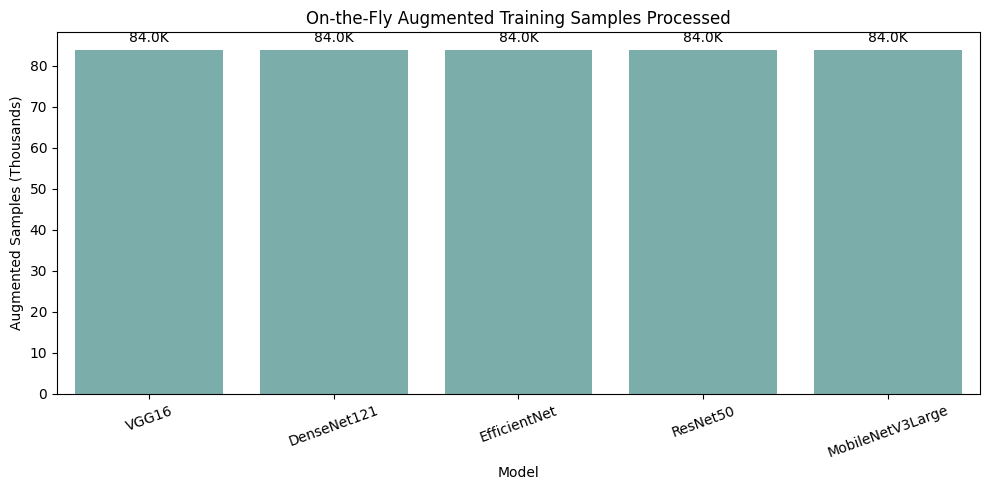

In [36]:
def calculate_augmentation_usage(parsed_models, train_image_map):
    """Audit augmentation code and calculate actual augmented samples processed."""
    train_count = sum(len(paths) for paths in train_image_map.values())
    rows = []
    for model in MODEL_ORDER:
        info = parsed_models.get(model)
        if not info:
            continue
        source = info["_source"]
        augmentation_used = bool(
            re.search(r"def\s+augment_image\s*\(", source)
            and re.search(r"augment_image\s*\(\s*image\s*\)", source)
        )
        brightness = bool(re.search(r"ImageEnhance\.Brightness", source))
        contrast = bool(re.search(r"ImageEnhance\.Contrast", source))
        saves_augmented_files = bool(
            re.search(r"save_to_dir\s*=", source)
            or re.search(r"(?:augmented_image|image|img)\.(?:save|imsave)\s*\(", source)
        )
        batch_size = info.get("Batch Size", np.nan)
        actual_epochs = info.get("Actual Epochs", np.nan)

        # The notebooks use: steps = int(len(train_paths) / batch_size).
        steps = int(train_count / batch_size) if train_count and pd.notna(batch_size) else np.nan
        samples_per_epoch = int(steps * batch_size) if pd.notna(steps) else np.nan
        augmented_processed = (
            int(samples_per_epoch * actual_epochs)
            if augmentation_used and pd.notna(samples_per_epoch) and pd.notna(actual_epochs)
            else 0 if not augmentation_used else np.nan
        )
        dropped_per_epoch = train_count - samples_per_epoch if pd.notna(samples_per_epoch) else np.nan

        # In the original notebooks, test_images = open_images(test_paths), and
        # open_images() calls augment_image(); this means reported evaluation used
        # stochastic brightness/contrast transformation when this pattern is present.
        test_augmentation = bool(
            augmentation_used
            and re.search(r"test_images\s*=\s*open_images\s*\(\s*test_paths\s*\)", source)
        )
        rows.append({
            "Model": model,
            "Augmentation Used": augmentation_used,
            "Operations": ", ".join(
                operation for operation, present in [
                    ("Random brightness", brightness),
                    ("Random contrast", contrast)
                ] if present
            ) or "Not available from saved experiment",
            "Training Images": train_count if train_count else np.nan,
            "Actual Epochs": actual_epochs,
            "Steps per Epoch": steps,
            "Samples Processed per Epoch": samples_per_epoch,
            "Augmented Samples Processed": augmented_processed,
            "Images Omitted per Epoch": dropped_per_epoch,
            "Augmented Files Saved to Disk": saves_augmented_files,
            "Augmentation Applied in Reported Test Evaluation": test_augmentation
        })
    return pd.DataFrame(rows)

augmentation_audit_df = calculate_augmentation_usage(parsed, train_images)
if augmentation_audit_df.empty or augmentation_audit_df["Training Images"].isna().all():
    show_unavailable("Augmentation count requires the discovered training dataset.")
else:
    display(augmentation_audit_df)
    augmentation_audit_df.to_csv(OUTPUT_DIR / "augmentation_audit.csv", index=False)

    total_processed = int(augmentation_audit_df["Augmented Samples Processed"].sum())
    per_model = augmentation_audit_df.set_index("Model")["Augmented Samples Processed"]
    print("Augmented samples processed during training (not saved unique files):")
    for model in MODEL_ORDER:
        if model in per_model.index:
            print(f"  {model}: {int(per_model[model]):,}")
    print(f"  Across all five experiments: {total_processed:,}")
    print("Permanently generated augmented dataset files: 0 (augmentation was performed on-the-fly).")
    print("Each epoch creates a new stochastic brightness/contrast view; counts do not imply every view is unique.")

    if augmentation_audit_df["Augmentation Applied in Reported Test Evaluation"].any():
        warnings.warn(
            "Notebook audit found that open_images(test_paths) called the same random "
            "augmentation function. Therefore the embedded reported test metrics were "
            "computed on stochastically brightness/contrast-adjusted test images. "
            "The aligned inference pipeline in this visualization notebook does not "
            "apply random augmentation to the held-out test set."
        )

    plt.figure(figsize=(10, 5))
    plot_data = augmentation_audit_df.copy()
    plot_data["Augmented Samples (Thousands)"] = plot_data["Augmented Samples Processed"] / 1000
    ax = sns.barplot(
        data=plot_data, x="Model", y="Augmented Samples (Thousands)",
        color="#72B7B2"
    )
    ax.set_title("On-the-Fly Augmented Training Samples Processed")
    ax.tick_params(axis="x", rotation=20)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1fK", padding=3)
    save_figure("02b_augmentation_samples.png")
    plt.show()

## 2. Experimental Configuration
### Five CNN Architectures
### Training Hyperparameters
### Fine-Tuning Strategy

Fine-tuning exposes selected upper-level pretrained layers to task-specific MRI learning. Recompiling with a reduced learning rate helps limit destructive changes to pretrained representations. This is a general machine-learning explanation, not medical advice.

,Model,Backbone,Input Size,Classes,Class Labels,Batch Size,Phase 1 Epochs,Phase 2 Max Epochs,Actual Epochs,Fine-Tuning Start Epoch,Phase 1 LR,Fine-Tune LR,Optimizer,Loss,Fine-Tuned Layers,Early Stopping,LR Scheduler,Preprocessing
0,VGG16,VGG16,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 4 backbone layers considered; BatchNorm f...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
1,DenseNet121,DenseNet121,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 40 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
2,EfficientNet,EfficientNetB0,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 30 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
3,ResNet50,ResNet50,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 20 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input
4,MobileNetV3Large,MobileNetV3Large,224,4,"glioma, meningioma, notumor, pituitary",20,5,10,15,6,0.001,0.00001,Adam,sparse_categorical_crossentropy,Last 20 backbone layers considered; BatchNorm ...,"monitor='loss', patience=3, restore_best_weigh...","monitor='loss', factor=0.5, patience=2, min_lr...",preprocess_input


,Model,Backbone Layer Window Unfrozen,Fine-Tuning Start Epoch,Phase 1 LR,Fine-Tune LR
0,VGG16,4,6,0.001,0.00001
1,DenseNet121,40,6,0.001,0.00001
2,EfficientNet,30,6,0.001,0.00001
3,ResNet50,20,6,0.001,0.00001
4,MobileNetV3Large,20,6,0.001,0.00001


All five experiments used the same batch size of 20.


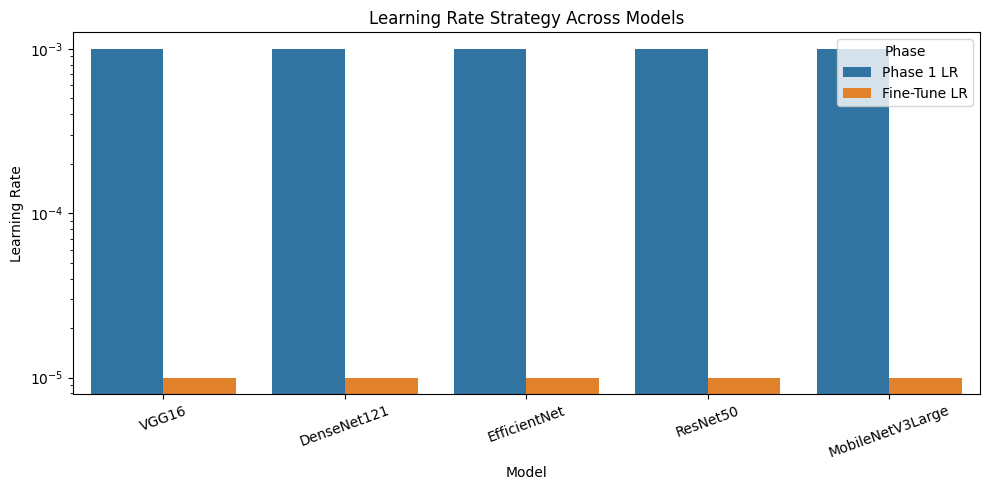

In [37]:
display(model_config_df[visible_columns])
fine_tuning_df = model_config_df[[
    "Model","Unfrozen Layer Window","Fine-Tuning Start Epoch","Phase 1 LR","Fine-Tune LR"
]].rename(columns={"Unfrozen Layer Window":"Backbone Layer Window Unfrozen"})
display(fine_tuning_df)

batch_values = model_config_df["Batch Size"].dropna().unique()
if len(batch_values) == 1:
    print(f"All five experiments used the same batch size of {int(batch_values[0])}.")
else:
    display(model_config_df[["Model","Batch Size"]])

lr_long = model_config_df.melt(id_vars="Model", value_vars=["Phase 1 LR","Fine-Tune LR"],
                               var_name="Phase", value_name="Learning Rate").dropna()
if not lr_long.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(data=lr_long, x="Model", y="Learning Rate", hue="Phase")
    plt.yscale("log"); plt.title("Learning Rate Strategy Across Models"); plt.xticks(rotation=20)
    save_figure("24_learning_rate_comparison.png"); plt.show()

## 3. Model Complexity
### Parameter Counts
### Trainable vs Frozen Parameters
### Model Size

,Model,Total Parameters,Trainable Parameters,Non-Trainable Parameters,Total Layers,Trainable Layers,Frozen Layers,Model File Size MB,Model Path
0,VGG16,14782916,7146628,7636288,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,111.006767,d:\Project-sem2\model_vgg16_v2.h5
1,DenseNet121,7173316,948868,6224448,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,35.445038,d:\Project-sem2\model_densenet121.h5
2,EfficientNet,4219175,1650404,2568771,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,29.161163,d:\Project-sem2\model_efficientnet.h5
3,ResNet50,23858692,9185924,14672768,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,161.497452,d:\Project-sem2\model_resnet50.h5
4,MobileNetV3Large,3123716,1072244,2051472,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,20.770632,d:\Project-sem2\model_mobilenetv3large.keras


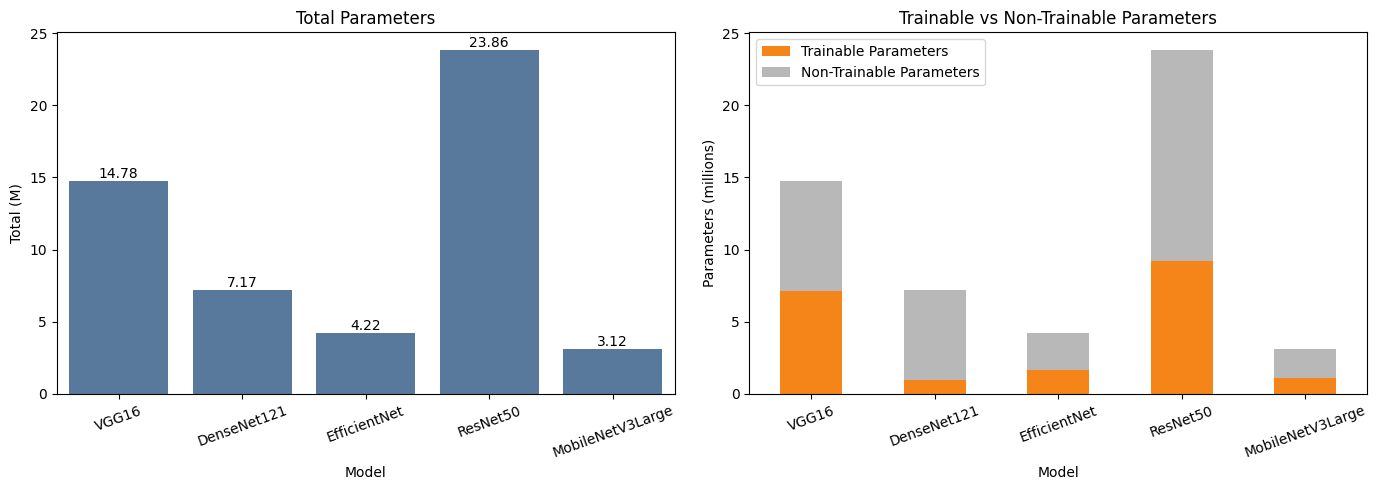

Layer counts require the saved model files; they are not inferred from parameter totals.


In [38]:
def locate_model_file(model_name, reference):
    """Match a saved model reference to a discovered artifact."""
    candidates = artifacts["models"]
    if reference:
        exact = [p for p in candidates if p.name == Path(reference).name]
        if exact: return exact[0]
    token = MODEL_TOKENS[model_name]
    return next((p for p in candidates if token in p.name.lower()), None)

parameter_rows = []
for _, row in model_config_df.iterrows():
    model_name = row["Model"]
    model_path = locate_model_file(model_name, row.get("Saved Model Reference"))
    parameter_rows.append({
        "Model": model_name, "Total Parameters": row["Total Parameters"],
        "Trainable Parameters": row["Trainable Parameters"], "Non-Trainable Parameters": row["Non-Trainable Parameters"],
        "Total Layers": np.nan, "Trainable Layers": np.nan, "Frozen Layers": np.nan,
        "Model File Size MB": model_path.stat().st_size/(1024**2) if model_path else np.nan,
        "Model Path": str(model_path) if model_path else "Not available from saved experiment"
    })
model_parameters_df = pd.DataFrame(parameter_rows)
display(model_parameters_df.fillna("Not available from saved experiment"))
model_parameters_df.to_csv(OUTPUT_DIR / "model_parameters.csv", index=False)

if model_parameters_df["Total Parameters"].notna().any():
    fig, axes = plt.subplots(1,2,figsize=(14,5))
    plot_df = model_parameters_df.copy()
    plot_df["Total (M)"] = plot_df["Total Parameters"]/1e6
    sns.barplot(data=plot_df, x="Model", y="Total (M)", ax=axes[0], color="#4C78A8")
    axes[0].set_title("Total Parameters"); axes[0].tick_params(axis="x", rotation=20)
    for c in axes[0].containers: axes[0].bar_label(c, fmt="%.2f")
    stacked = plot_df.set_index("Model")[["Trainable Parameters","Non-Trainable Parameters"]]/1e6
    stacked.plot(kind="bar", stacked=True, ax=axes[1], color=["#F58518","#B8B8B8"], rot=20)
    axes[1].set_title("Trainable vs Non-Trainable Parameters"); axes[1].set_ylabel("Parameters (millions)")
    save_figure("03_model_parameters.png"); plt.show()
print("Layer counts require the saved model files; they are not inferred from parameter totals.")

## 4. Training Behaviour
### Training Accuracy
### Training Loss
### Fine-Tuning Transition
### Epoch Comparison

,Epoch,Model,Phase,Training Accuracy,Training Loss,Learning Rate,Epoch Time Seconds,Phase Configured Maximum
0,1,VGG16,Frozen Feature Extraction,0.7011,0.8251,NaN,1927.0,5
1,2,VGG16,Frozen Feature Extraction,0.8538,0.3792,NaN,1941.0,5
2,3,VGG16,Frozen Feature Extraction,0.8866,0.3057,NaN,1701.0,5
3,4,VGG16,Frozen Feature Extraction,0.9082,0.2364,NaN,1510.0,5
4,5,VGG16,Frozen Feature Extraction,0.9172,0.2263,NaN,1037.0,5


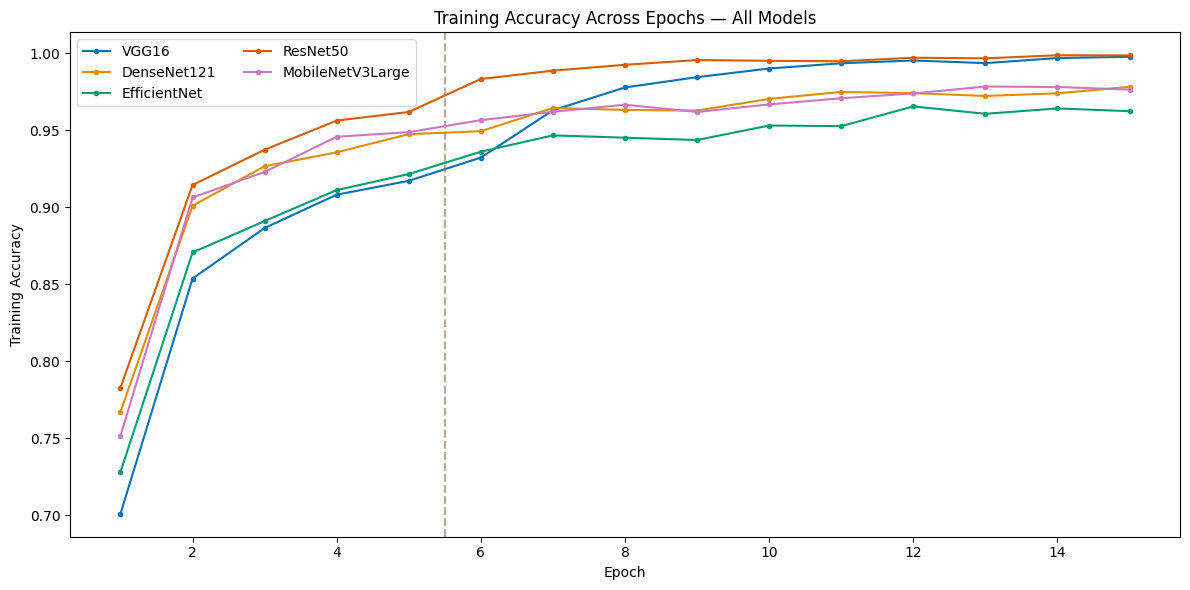

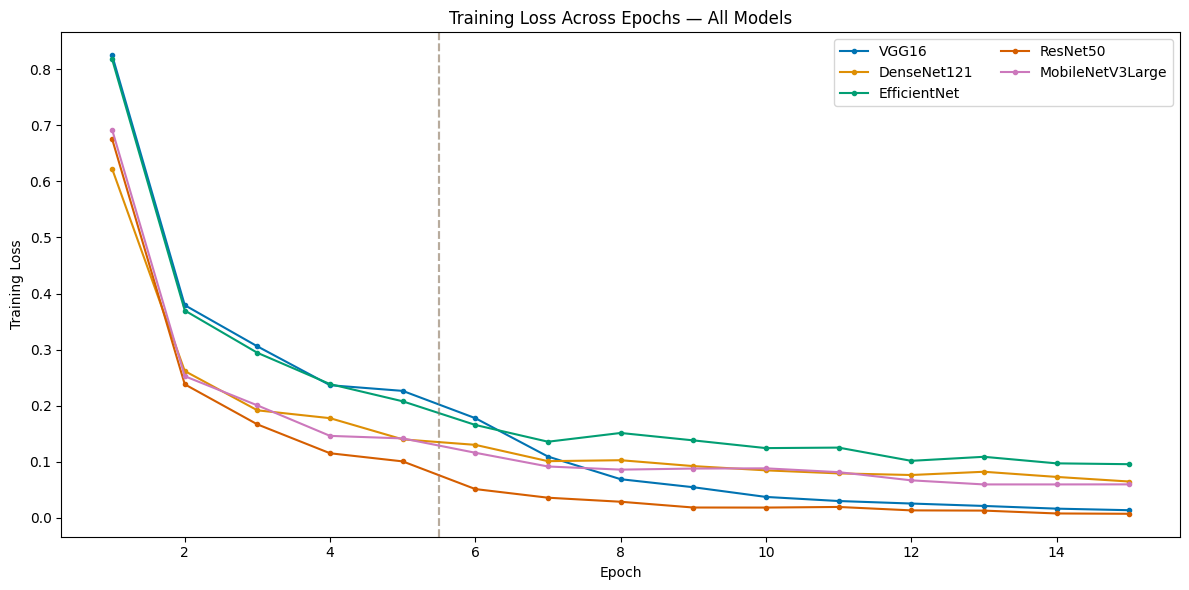

,Model,Best Training Accuracy,Final Training Accuracy,Final Training Loss,Actual Epochs
0,VGG16,0.9977,0.9977,0.0134,15
1,DenseNet121,0.9782,0.9782,0.0646,15
2,EfficientNet,0.9655,0.9624,0.0955,15
3,ResNet50,0.9987,0.9986,0.0070,15
4,MobileNetV3Large,0.9784,0.9764,0.0595,15


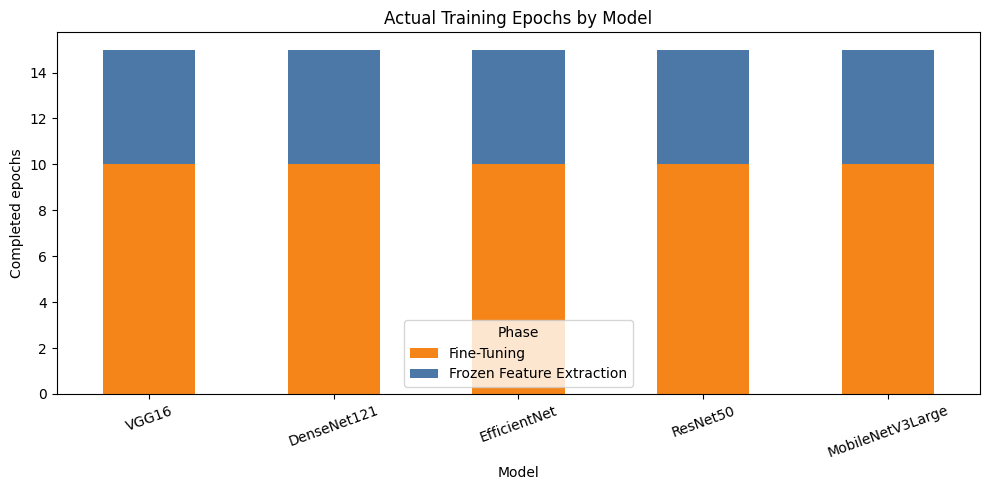

In [39]:
EPOCH_RE = re.compile(
    r"Epoch\s+(\d+)/(\d+).*?(?=\nEpoch\s+\d+/\d+|\Z)", re.S
)
def load_history_from_notebook(model_name, parsed_row):
    """Extract only epoch metrics actually printed in notebook outputs."""
    records = []
    phase_counter = 0
    prior_epoch = None
    for block in EPOCH_RE.finditer(parsed_row["_output"]):
        epoch_in_phase, phase_max = map(int, block.group(1,2))
        if prior_epoch is not None and epoch_in_phase <= prior_epoch:
            phase_counter += 1
        prior_epoch = epoch_in_phase
        text = block.group(0)
        accs = re.findall(r"(?:sparse_categorical_accuracy|accuracy):\s*([0-9.]+)", text)
        losses = re.findall(r"loss:\s*([0-9.]+)", text)
        lrs = re.findall(r"learning_rate:\s*([0-9.eE+-]+)", text)
        records.append({
            "Epoch": len(records)+1, "Model": model_name,
            "Phase": "Frozen Feature Extraction" if phase_counter == 0 else "Fine-Tuning",
            "Training Accuracy": float(accs[-1]) if accs else np.nan,
            "Training Loss": float(losses[-1]) if losses else np.nan,
            "Learning Rate": float(lrs[-1]) if lrs else np.nan,
            "Epoch Time Seconds": float(first_match(r"\s(\d+)s\s+\d+s/step", text)) if re.search(r"\s(\d+)s\s+\d+s/step", text) else np.nan,
            "Phase Configured Maximum": phase_max
        })
    return records

training_history_df = pd.DataFrame([
    record for model, row in parsed.items() for record in load_history_from_notebook(model, row)
])
display(training_history_df.head())
training_history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

def plot_training_history(metric, filename):
    """Plot a recorded training metric for every model."""
    if training_history_df.empty or training_history_df[metric].notna().sum() == 0:
        return show_unavailable(f"{metric} is not available from saved experiment.")
    plt.figure(figsize=(12,6))
    for model in MODEL_ORDER:
        part = training_history_df[training_history_df.Model == model]
        if not part.empty:
            plt.plot(part.Epoch, part[metric], marker="o", ms=3, label=model, color=COLORS[model])
            transition = part.loc[part.Phase.eq("Fine-Tuning"), "Epoch"].min()
            if pd.notna(transition): plt.axvline(transition-0.5, color=COLORS[model], alpha=.18, ls="--")
    plt.title(f"{metric} Across Epochs — All Models"); plt.xlabel("Epoch"); plt.ylabel(metric)
    plt.legend(ncol=2); save_figure(filename); plt.show()

plot_training_history("Training Accuracy", "04_training_accuracy_comparison.png")
plot_training_history("Training Loss", "05_training_loss_comparison.png")

training_summary_df = training_history_df.groupby("Model", as_index=False).agg(
    **{"Best Training Accuracy":("Training Accuracy","max"),
       "Final Training Accuracy":("Training Accuracy","last"),
       "Final Training Loss":("Training Loss","last"),
       "Actual Epochs":("Epoch","max")}
).set_index("Model").reindex(MODEL_ORDER).reset_index()
display(training_summary_df)

epoch_phase = training_history_df.groupby(["Model","Phase"]).size().unstack(fill_value=0).reindex(MODEL_ORDER)
epoch_phase.plot(kind="bar", stacked=True, figsize=(10,5), color=["#F58518","#4C78A8"])
plt.title("Actual Training Epochs by Model"); plt.ylabel("Completed epochs"); plt.xticks(rotation=20)
save_figure("23_epoch_comparison.png"); plt.show()

## 5. Overall Test Performance
### Accuracy
### Precision
### Recall
### F1 Score
### Training vs Test Accuracy

The rounded classification reports embedded in the original notebooks are retained as provenance, but the primary comparison below accepts only cached or newly inferred probabilities whose image paths, ordering, labels, and class order pass the explicit fair-comparison check.

In [40]:
def canonical_test_manifest(test_dir):
    """Create one immutable, sorted test manifest shared by all models."""
    mapping = image_paths_by_class(test_dir)
    classes = sorted(mapping)
    rows = [{"image_path":str(p.resolve()), "class_name":cls, "true_label":i}
            for i, cls in enumerate(classes) for p in mapping[cls]]
    return pd.DataFrame(rows), classes

test_manifest, CLASS_NAMES = canonical_test_manifest(TEST_DIR)
print(f"Canonical test images: {len(test_manifest)}")
print("Canonical class order:", CLASS_NAMES or "Not available from saved experiment")

def preprocessing_for(model_name):
    """Return the architecture-specific Keras preprocessing function verified by notebook imports."""
    if not TF_AVAILABLE: return None
    if model_name == "VGG16":
        from tensorflow.keras.applications.vgg16 import preprocess_input
    elif model_name == "DenseNet121":
        from tensorflow.keras.applications.densenet import preprocess_input
    elif model_name == "EfficientNet":
        from tensorflow.keras.applications.efficientnet import preprocess_input
    elif model_name == "ResNet50":
        from tensorflow.keras.applications.resnet50 import preprocess_input
    elif model_name == "MobileNetV3Large":
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
    else:
        raise ValueError(model_name)
    return preprocess_input

def cache_path(model_name):
    return CACHE_DIR / f"{model_name.lower()}_predictions.npz"

def valid_cache(path, manifest, class_names):
    """Validate cached path order, labels and class order."""
    if not path.exists(): return False
    try:
        data = np.load(path, allow_pickle=False)
        return (np.array_equal(data["image_paths"].astype(str), manifest.image_path.to_numpy(str))
                and np.array_equal(data["true_labels"], manifest.true_label.to_numpy())
                and np.array_equal(data["class_names"].astype(str), np.asarray(class_names, dtype=str))
                and len(data["probabilities"]) == len(manifest))
    except Exception:
        return False

def predict_model(model_name, model_path, input_size, manifest, class_names):
    """Load a trained model and predict the canonical test manifest in deterministic batches."""
    if not TF_AVAILABLE: raise RuntimeError("TensorFlow is unavailable.")
    preprocess = preprocessing_for(model_name)
    paths = manifest.image_path.to_numpy(str)
    labels = manifest.true_label.to_numpy(np.int64)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def load_one(path, label):
        image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
        image = tf.image.resize(image, [int(input_size), int(input_size)])
        return tf.cast(image, tf.float32), label
    ds = ds.map(load_one, num_parallel_calls=tf.data.AUTOTUNE).batch(INFERENCE_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    model = load_model(model_path)
    probabilities = []
    for images, _ in ds:
        probabilities.append(model.predict(preprocess(images), verbose=0))
    probabilities = np.concatenate(probabilities)
    predicted = probabilities.argmax(axis=1)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(cache_path(model_name), image_paths=paths, true_labels=labels,
                        predicted_labels=predicted, probabilities=probabilities,
                        class_names=np.asarray(class_names, dtype=str))
    return np.load(cache_path(model_name), allow_pickle=False)

prediction_data = {}
for _, cfg in model_config_df.iterrows():
    model = cfg["Model"]; cp = cache_path(model)
    if valid_cache(cp, test_manifest, CLASS_NAMES):
        prediction_data[model] = np.load(cp, allow_pickle=False)
        print(f"{model}: reused valid aligned cache")
    elif RUN_MODEL_INFERENCE:
        mp = locate_model_file(model, cfg["Saved Model Reference"])
        if mp and len(test_manifest):
            try:
                prediction_data[model] = predict_model(model, mp, cfg["Input Size"], test_manifest, CLASS_NAMES)
                print(f"{model}: inference complete and cached")
            except Exception as exc:
                print(f"{model}: inference skipped because its saved model is incompatible with this TensorFlow/Keras version; using its saved report instead.")
        else:
            print(f"{model}: model or test dataset unavailable; inference skipped")
    else:
        print(f"{model}: no valid cache; set RUN_MODEL_INFERENCE=True when model and dataset artifacts are available")

fair_comparison = (
    len(prediction_data) == len(MODEL_ORDER)
    and CLASS_NAMES == EXPECTED_CLASSES
    and all(np.array_equal(d["image_paths"].astype(str), test_manifest.image_path.to_numpy(str)) for d in prediction_data.values())
    and all(np.array_equal(d["true_labels"], test_manifest.true_label.to_numpy()) for d in prediction_data.values())
    and all(np.array_equal(d["class_names"].astype(str), np.asarray(CLASS_NAMES, dtype=str)) for d in prediction_data.values())
)
if fair_comparison:
    print("Fair comparison check passed")
else:
    warnings.warn("Live aligned inference is unavailable; saved training-notebook metrics and plots will be used when present.")

# Fallback: recover held-out test metrics already embedded in each training notebook.
REPORT_RE = re.compile(r"^\s*(glioma|meningioma|notumor|pituitary)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s*$", re.M)
reported_per_class_rows, reported_overall_rows = [], []
for model in MODEL_ORDER:
    text = parsed[model]["_output"]
    rows = {name: (float(p), float(r), float(f), int(s)) for name, p, r, f, s in REPORT_RE.findall(text)}
    accuracy_match = re.search(r"^\s*accuracy\s+(\d+\.\d+)\s+\d+\s*$", text, re.M)
    macro_match = re.search(r"^\s*macro avg\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+\d+\s*$", text, re.M)
    if set(rows) == set(EXPECTED_CLASSES) and accuracy_match and macro_match:
        for cls in EXPECTED_CLASSES:
            p, r, f, s = rows[cls]; reported_per_class_rows.append({"Model":model, "Class":cls, "Precision":p, "Recall":r, "F1":f, "Support":s})
        mp, mr, mf = map(float, macro_match.groups())
        reported_overall_rows.append({"Model":model, "Accuracy":float(accuracy_match.group(1)), "Macro Precision":mp, "Macro Recall":mr, "Macro F1":mf, "Weighted Precision":np.nan, "Weighted Recall":np.nan, "Weighted F1":np.nan, "Macro AUC":np.nan, "Weighted AUC":np.nan})
reported_overall_metrics_df = pd.DataFrame(reported_overall_rows)
reported_per_class_metrics_df = pd.DataFrame(reported_per_class_rows)
reported_comparison = len(reported_overall_metrics_df) == len(MODEL_ORDER)
comparison_label = "aligned live inference" if fair_comparison else "reported test metrics saved in the training notebooks"
if reported_comparison and not fair_comparison:
    print("Using reported held-out test metrics from all five saved training notebooks for ranking.")

Canonical test images: 1600
Canonical class order: ['glioma', 'meningioma', 'notumor', 'pituitary']
VGG16: inference skipped because its saved model is incompatible with this TensorFlow/Keras version; using its saved report instead.
DenseNet121: inference skipped because its saved model is incompatible with this TensorFlow/Keras version; using its saved report instead.
EfficientNet: inference skipped because its saved model is incompatible with this TensorFlow/Keras version; using its saved report instead.
ResNet50: inference skipped because its saved model is incompatible with this TensorFlow/Keras version; using its saved report instead.
MobileNetV3Large: inference skipped because its saved model is incompatible with this TensorFlow/Keras version; using its saved report instead.
Using reported held-out test metrics from all five saved training notebooks for ranking.


C:\Users\Samir\AppData\Local\Temp\ipykernel_6628\2742346423.py:98: UserWarning: Live aligned inference is unavailable; saved training-notebook metrics and plots will be used when present.
  warnings.warn("Live aligned inference is unavailable; saved training-notebook metrics and plots will be used when present.")


Comparison source: reported test metrics saved in the training notebooks


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Macro AUC,Weighted AUC
0,VGG16,0.94,0.94,0.94,0.94,NaN,NaN,NaN,NaN,NaN
1,DenseNet121,0.92,0.93,0.92,0.92,NaN,NaN,NaN,NaN,NaN
2,EfficientNet,0.92,0.93,0.92,0.92,NaN,NaN,NaN,NaN,NaN
3,ResNet50,0.92,0.92,0.92,0.92,NaN,NaN,NaN,NaN,NaN
4,MobileNetV3Large,0.93,0.93,0.93,0.92,NaN,NaN,NaN,NaN,NaN


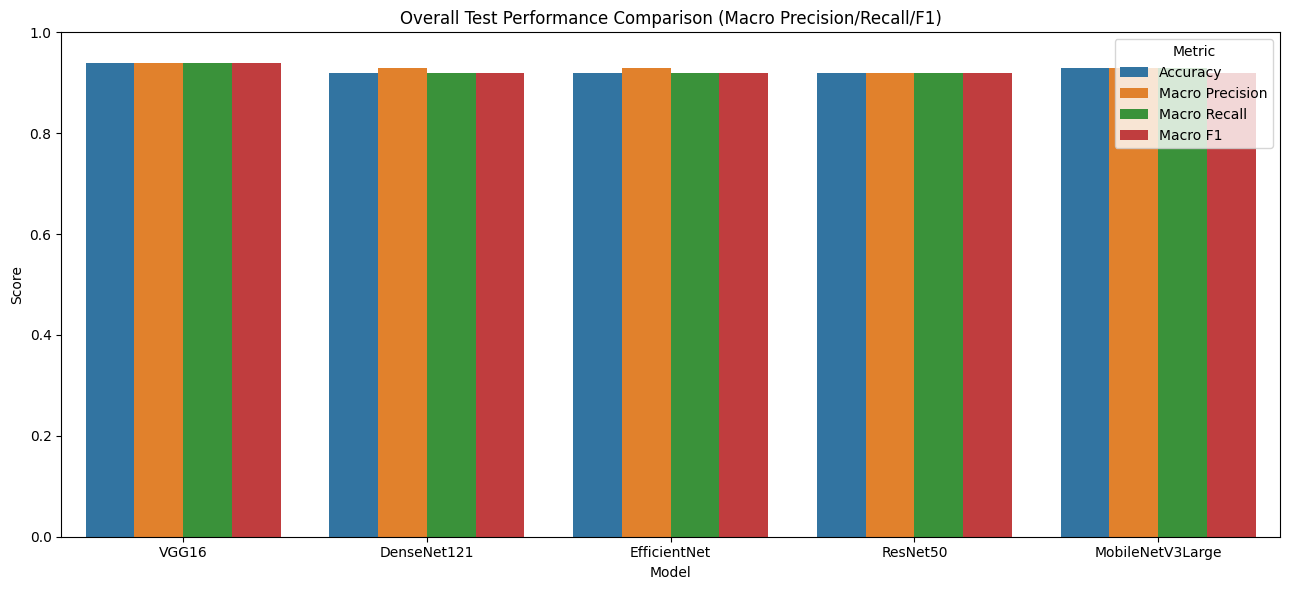

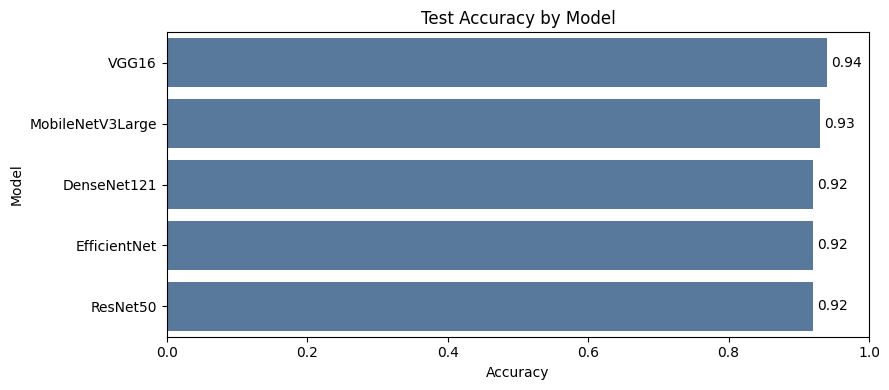

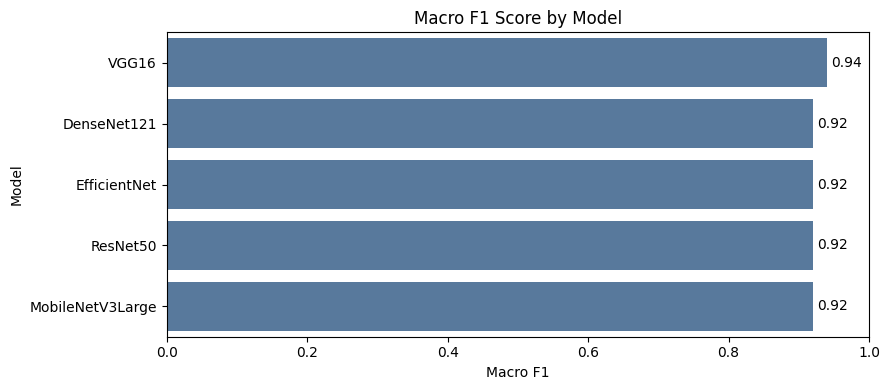

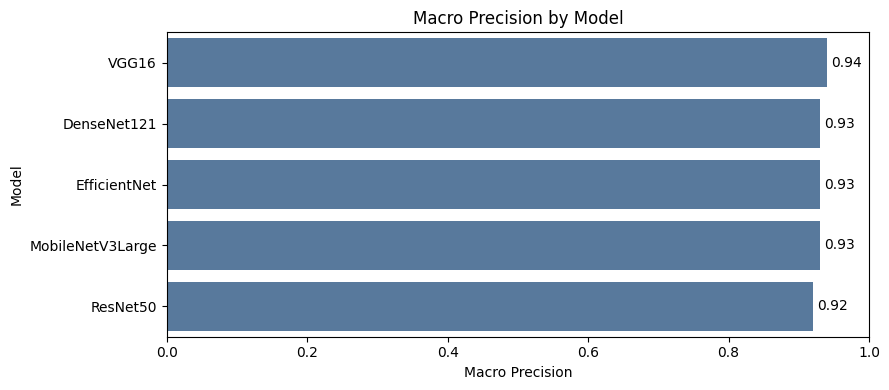

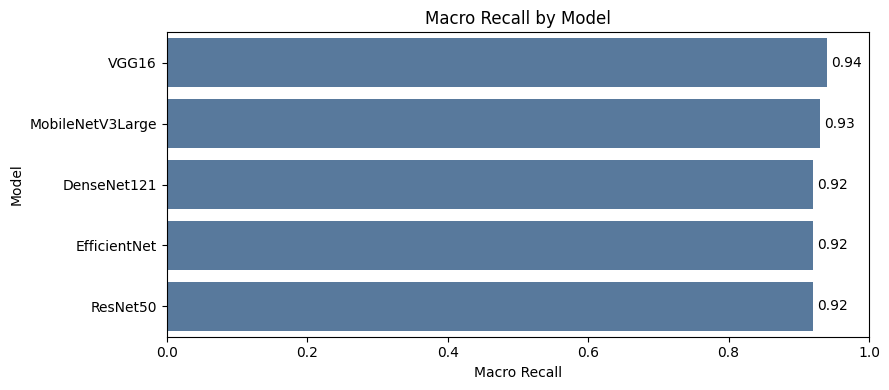

In [41]:
def calculate_metrics(model_name, data):
    """Calculate overall metrics from aligned labels and probabilities."""
    y, pred, prob = data["true_labels"], data["predicted_labels"], data["probabilities"]
    y_bin = label_binarize(y, classes=np.arange(len(CLASS_NAMES)))
    return {
        "Model":model_name, "Accuracy":accuracy_score(y,pred),
        "Macro Precision":precision_score(y,pred,average="macro",zero_division=0),
        "Macro Recall":recall_score(y,pred,average="macro",zero_division=0),
        "Macro F1":f1_score(y,pred,average="macro",zero_division=0),
        "Weighted Precision":precision_score(y,pred,average="weighted",zero_division=0),
        "Weighted Recall":recall_score(y,pred,average="weighted",zero_division=0),
        "Weighted F1":f1_score(y,pred,average="weighted",zero_division=0),
        "Macro AUC":roc_auc_score(y_bin,prob,average="macro",multi_class="ovr"),
        "Weighted AUC":roc_auc_score(y_bin,prob,average="weighted",multi_class="ovr")
    }

overall_metrics_df = (pd.DataFrame([calculate_metrics(m,prediction_data[m]) for m in MODEL_ORDER]) if fair_comparison else reported_overall_metrics_df.copy())
if overall_metrics_df.empty:
    show_unavailable("Comparable overall metrics: Not available from saved experiment (aligned probability inference required).")
else:
    print(f"Comparison source: {comparison_label}")
    display(overall_metrics_df)
    overall_metrics_df.to_csv(OUTPUT_DIR / "overall_model_metrics.csv", index=False)
    long = overall_metrics_df.melt("Model", ["Accuracy","Macro Precision","Macro Recall","Macro F1"], "Metric","Score")
    plt.figure(figsize=(13,6)); sns.barplot(data=long,x="Model",y="Score",hue="Metric")
    plt.ylim(0,1); plt.title("Overall Test Performance Comparison (Macro Precision/Recall/F1)")
    save_figure("07_metrics_comparison.png"); plt.show()
    for metric, title, filename in [
        ("Accuracy","Test Accuracy by Model","06_test_accuracy.png"),
        ("Macro F1","Macro F1 Score by Model","08_f1_comparison.png"),
        ("Macro Precision","Macro Precision by Model","09_precision_comparison.png"),
        ("Macro Recall","Macro Recall by Model","10_recall_comparison.png")]:
        rank = overall_metrics_df.sort_values(metric, ascending=False)
        plt.figure(figsize=(9,4)); ax=sns.barplot(data=rank,x=metric,y="Model",color="#4C78A8")
        ax.set_xlim(0,1); ax.set_title(title)
        for c in ax.containers: ax.bar_label(c, fmt="%.2f", padding=3)
        save_figure(filename); plt.show()

## 6. Per-Class Performance
### Precision Heatmap
### Recall Heatmap
### F1 Heatmap

,Model,Class,Precision,Recall,F1,Support
0,VGG16,glioma,0.97,0.81,0.88,400
1,VGG16,meningioma,0.90,0.94,0.92,400
2,VGG16,notumor,0.92,1.00,0.96,400
3,VGG16,pituitary,0.97,0.99,0.98,400
4,DenseNet121,glioma,0.97,0.76,0.85,400
5,DenseNet121,meningioma,0.85,0.95,0.90,400
6,DenseNet121,notumor,0.92,1.00,0.96,400
7,DenseNet121,pituitary,0.97,0.98,0.98,400
8,EfficientNet,glioma,0.98,0.74,0.84,400
9,EfficientNet,meningioma,0.85,0.95,0.90,400


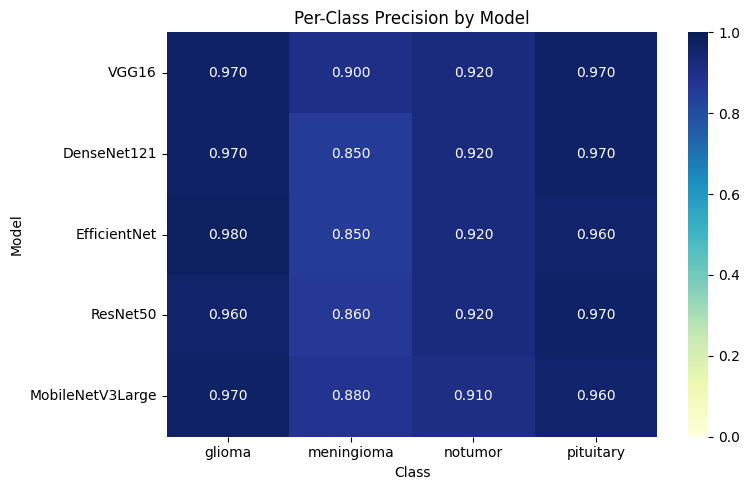

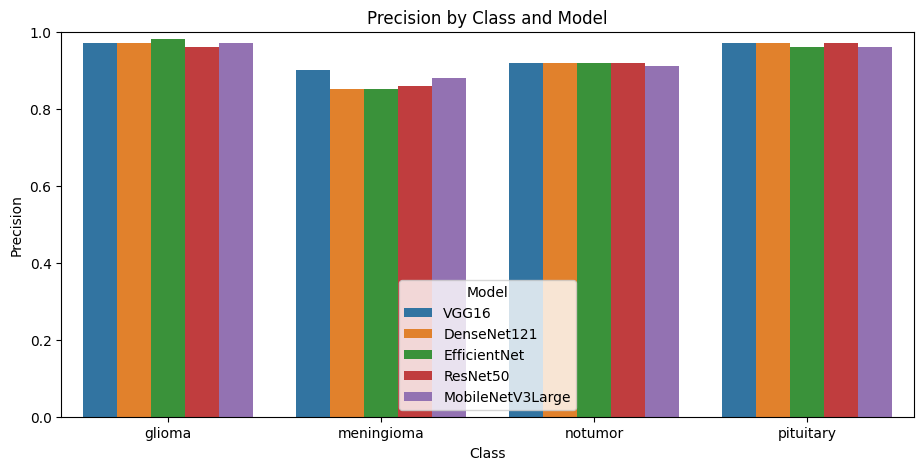

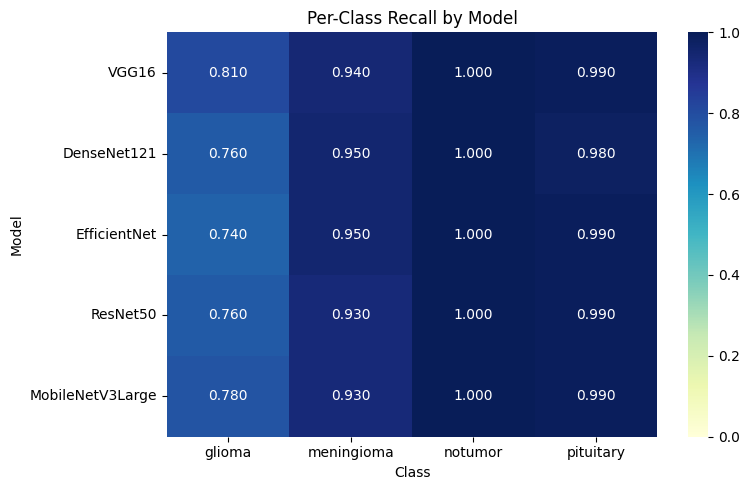

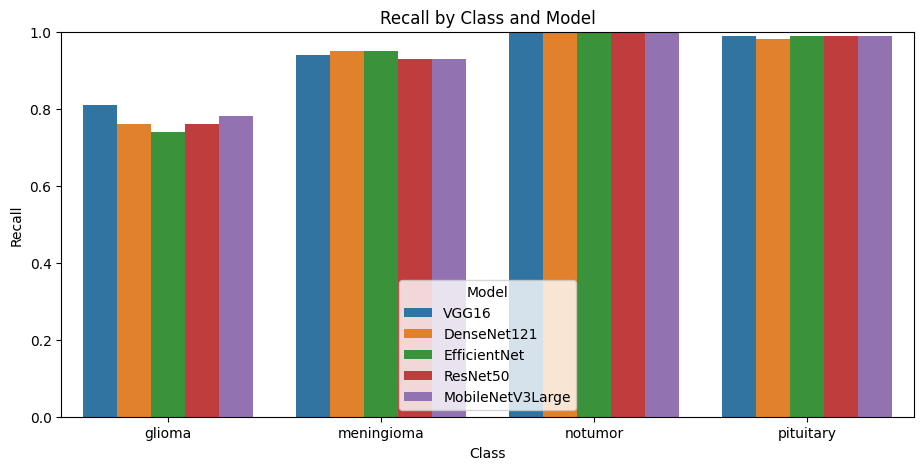

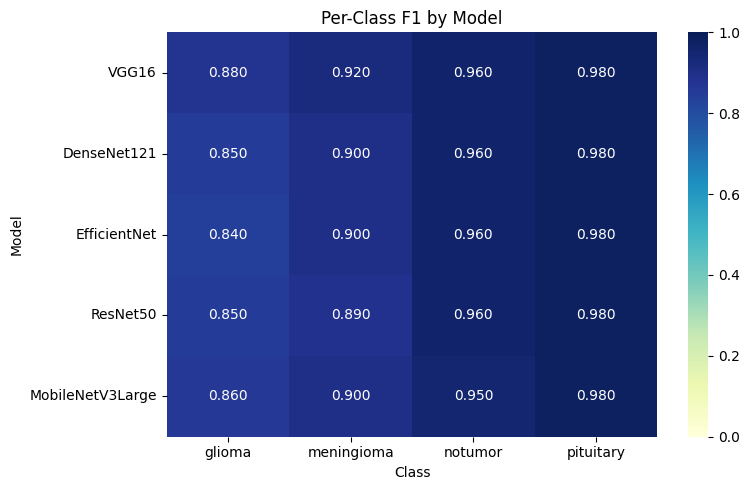

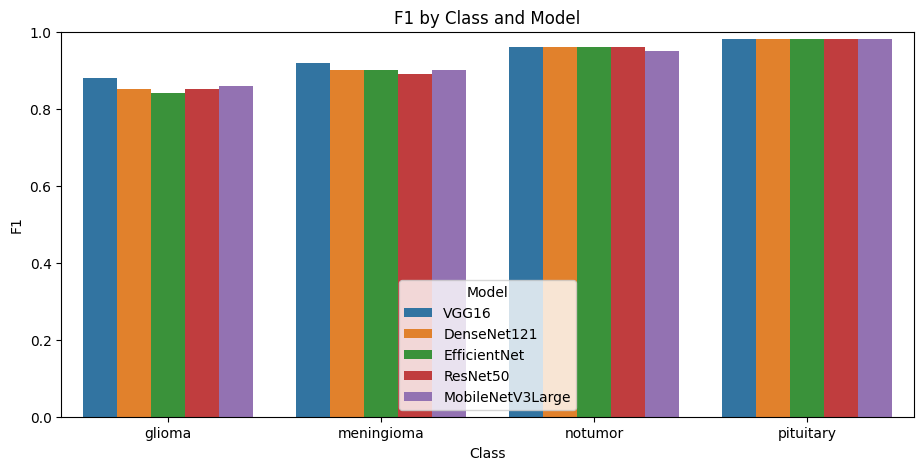

In [42]:
def calculate_per_class_metrics(model_name, data):
    """Return tidy class-level metrics."""
    report = classification_report(data["true_labels"], data["predicted_labels"],
                                   labels=np.arange(len(CLASS_NAMES)), target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    return [{"Model":model_name,"Class":cls,"Precision":report[cls]["precision"],
             "Recall":report[cls]["recall"],"F1":report[cls]["f1-score"],"Support":report[cls]["support"]}
            for cls in CLASS_NAMES]

per_class_metrics_df = (pd.DataFrame([
    row for model in MODEL_ORDER for row in calculate_per_class_metrics(model,prediction_data[model])
]) if fair_comparison else reported_per_class_metrics_df.copy())
if per_class_metrics_df.empty:
    show_unavailable()
else:
    display(per_class_metrics_df)
    per_class_metrics_df.to_csv(OUTPUT_DIR/"per_class_metrics.csv",index=False)
    for metric, filename in [("Precision","13_per_class_precision_heatmap.png"),
                             ("Recall","13_per_class_recall_heatmap.png"),("F1","12_per_class_f1_heatmap.png")]:
        pivot=per_class_metrics_df.pivot(index="Model",columns="Class",values=metric).reindex(MODEL_ORDER)
        plt.figure(figsize=(8,5)); sns.heatmap(pivot,annot=True,fmt=".3f",vmin=0,vmax=1,cmap="YlGnBu")
        plt.title(f"Per-Class {metric} by Model"); save_figure(filename); plt.show()
        plt.figure(figsize=(11,5)); sns.barplot(data=per_class_metrics_df,x="Class",y=metric,hue="Model")
        plt.ylim(0,1); plt.title(f"{metric} by Class and Model"); plt.show()

## 7. Confusion Matrix Analysis
### Raw Confusion Matrices
### Normalized Confusion Matrices
### Common Misclassification Patterns

Not available from saved experiment
Not available from saved experiment
Showing the confusion matrices saved during each model's original test run.


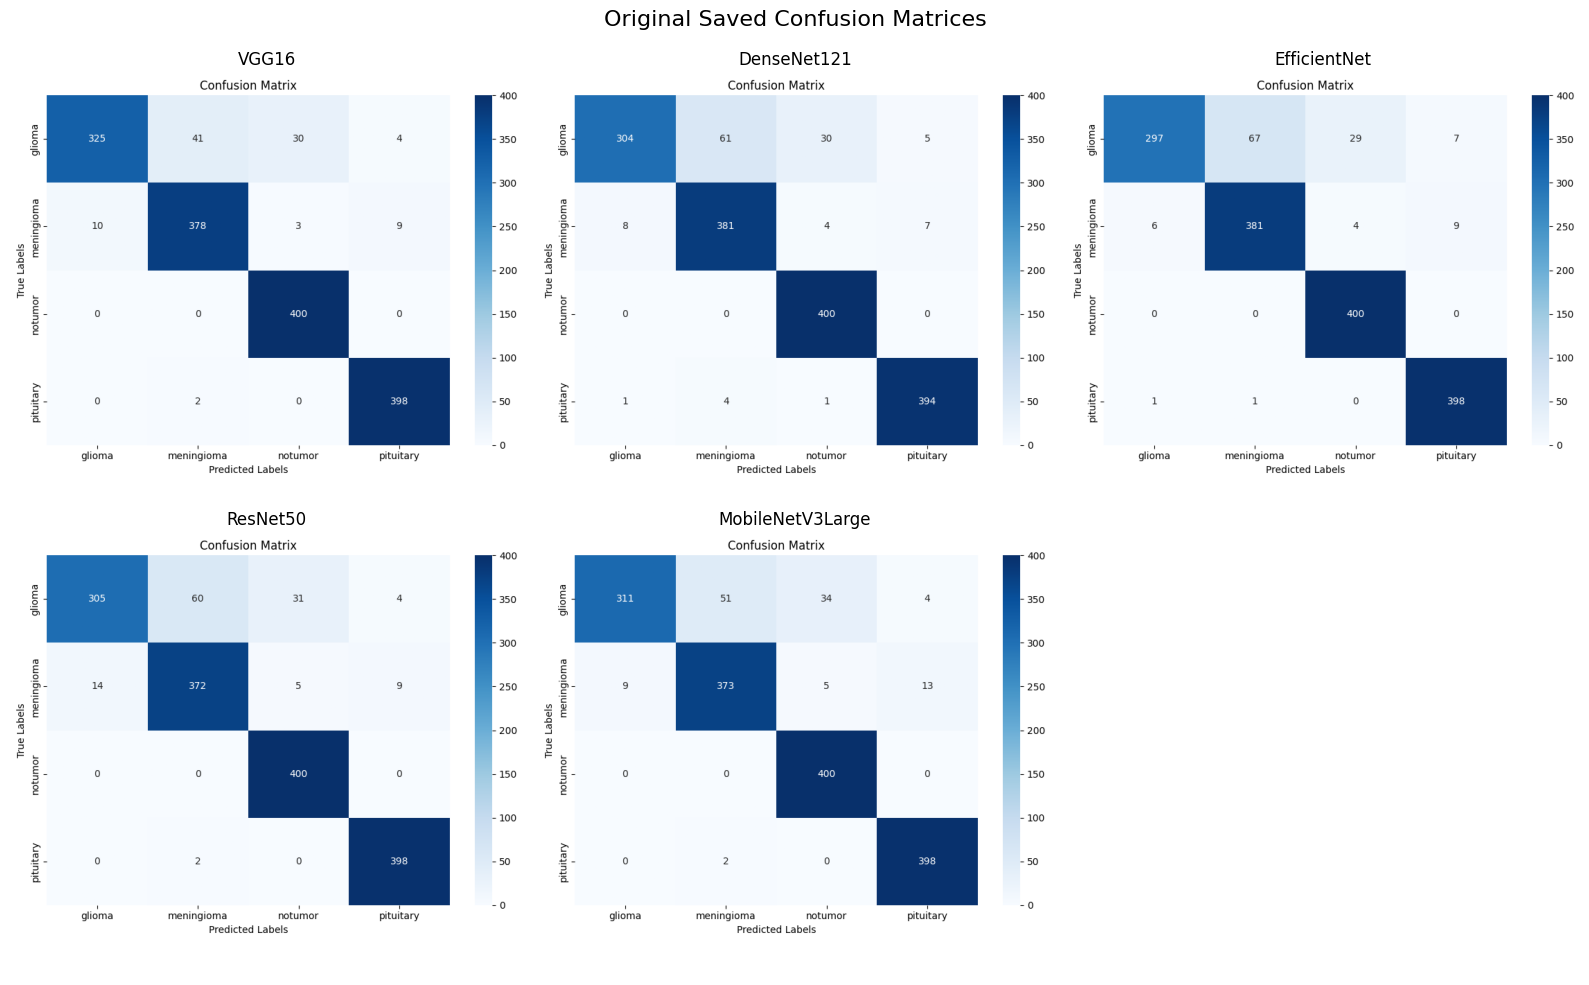

,Model,Incorrect Predictions
0,VGG16,NaN
1,DenseNet121,NaN
2,EfficientNet,NaN
3,ResNet50,NaN
4,MobileNetV3Large,NaN


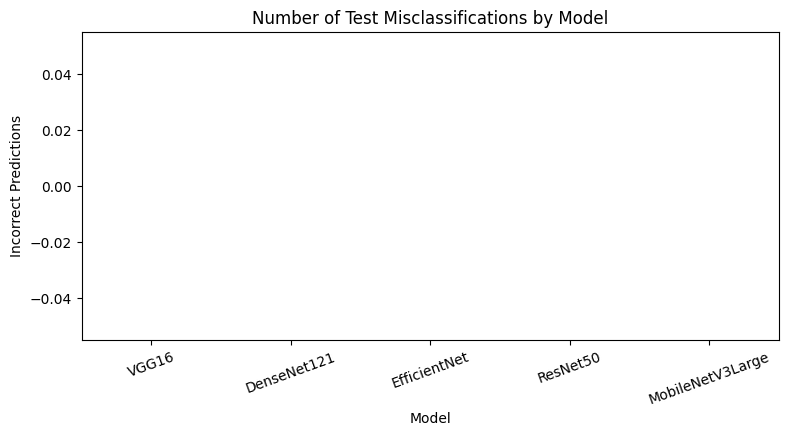

In [43]:
def show_archived_training_plots(cell_index, title, filename):
    """Show the original plot saved in every training notebook."""
    import base64
    from io import BytesIO
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for ax, model in zip(axes.flat, MODEL_ORDER):
        ax.axis("off")
        cell = parsed[model]["_doc"]["cells"][cell_index]
        png = next((o.get("data", {}).get("image/png") for o in cell.get("outputs", []) if o.get("data", {}).get("image/png")), None)
        if png:
            ax.imshow(plt.imread(BytesIO(base64.b64decode(png)), format="png")); ax.set_title(model)
        else: ax.text(.5, .5, "Saved plot unavailable", ha="center")
    axes.flat[-1].axis("off"); fig.suptitle(title, fontsize=16); save_figure(filename); plt.show()

def plot_confusion_matrices(normalize=None, filename="14_confusion_matrices.png"):
    """Plot all five confusion matrices on the same class order."""
    if not fair_comparison: return show_unavailable()
    matrices=[confusion_matrix(prediction_data[m]["true_labels"],prediction_data[m]["predicted_labels"],
                               labels=np.arange(len(CLASS_NAMES)),normalize=normalize) for m in MODEL_ORDER]
    vmax=max(x.max() for x in matrices)
    fig,axes=plt.subplots(2,3,figsize=(17,10))
    for ax,matrix,model in zip(axes.flat,matrices,MODEL_ORDER):
        sns.heatmap(matrix,annot=True,fmt=".2%" if normalize else "d",cmap="Blues",vmin=0,vmax=vmax,
                    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax,cbar=False)
        ax.set_title(model); ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
    axes.flat[-1].axis("off")
    fig.suptitle("Normalized Confusion Matrices" if normalize else "Confusion Matrices",fontsize=16)
    save_figure(filename); plt.show()

plot_confusion_matrices(None,"14_confusion_matrices.png")
plot_confusion_matrices("true","15_normalized_confusion_matrices.png")
if not fair_comparison:
    print("Showing the confusion matrices saved during each model's original test run.")
    show_archived_training_plots(16, "Original Saved Confusion Matrices", "14_saved_confusion_matrices.png")

confusion_rows=[]
if fair_comparison:
    for model in MODEL_ORDER:
        cm=confusion_matrix(prediction_data[model]["true_labels"],prediction_data[model]["predicted_labels"],
                            labels=np.arange(len(CLASS_NAMES)))
        off=cm.copy(); np.fill_diagonal(off,0); i,j=np.unravel_index(np.argmax(off),off.shape)
        confusion_rows.append({"Model":model,"Correct Predictions":int(np.trace(cm)),
            "Incorrect Predictions":int(cm.sum()-np.trace(cm)),"Error Rate":1-np.trace(cm)/cm.sum(),
            "Most Confused True Class":CLASS_NAMES[i],"Most Confused Predicted Class":CLASS_NAMES[j],
            "Count":int(off[i,j])})
confusion_summary_df=pd.DataFrame(confusion_rows)
if confusion_summary_df.empty and reported_comparison:
    confusion_summary_df = pd.DataFrame({"Model": MODEL_ORDER, "Incorrect Predictions": np.nan})
if confusion_summary_df.empty: show_unavailable()
else:
    display(confusion_summary_df); confusion_summary_df.to_csv(OUTPUT_DIR/"confusion_summary.csv",index=False)
    plt.figure(figsize=(9,4)); sns.barplot(data=confusion_summary_df.sort_values("Incorrect Predictions"),
        x="Model",y="Incorrect Predictions",color="#E45756")
    plt.title("Number of Test Misclassifications by Model"); plt.xticks(rotation=20); plt.show()

## 8. ROC and AUC Analysis
### ROC Curve for Each Model
### Model-Level ROC Comparison
### AUC Heatmap

Exact ROC/AUC values require class probabilities; showing the ROC curves saved during the original runs.


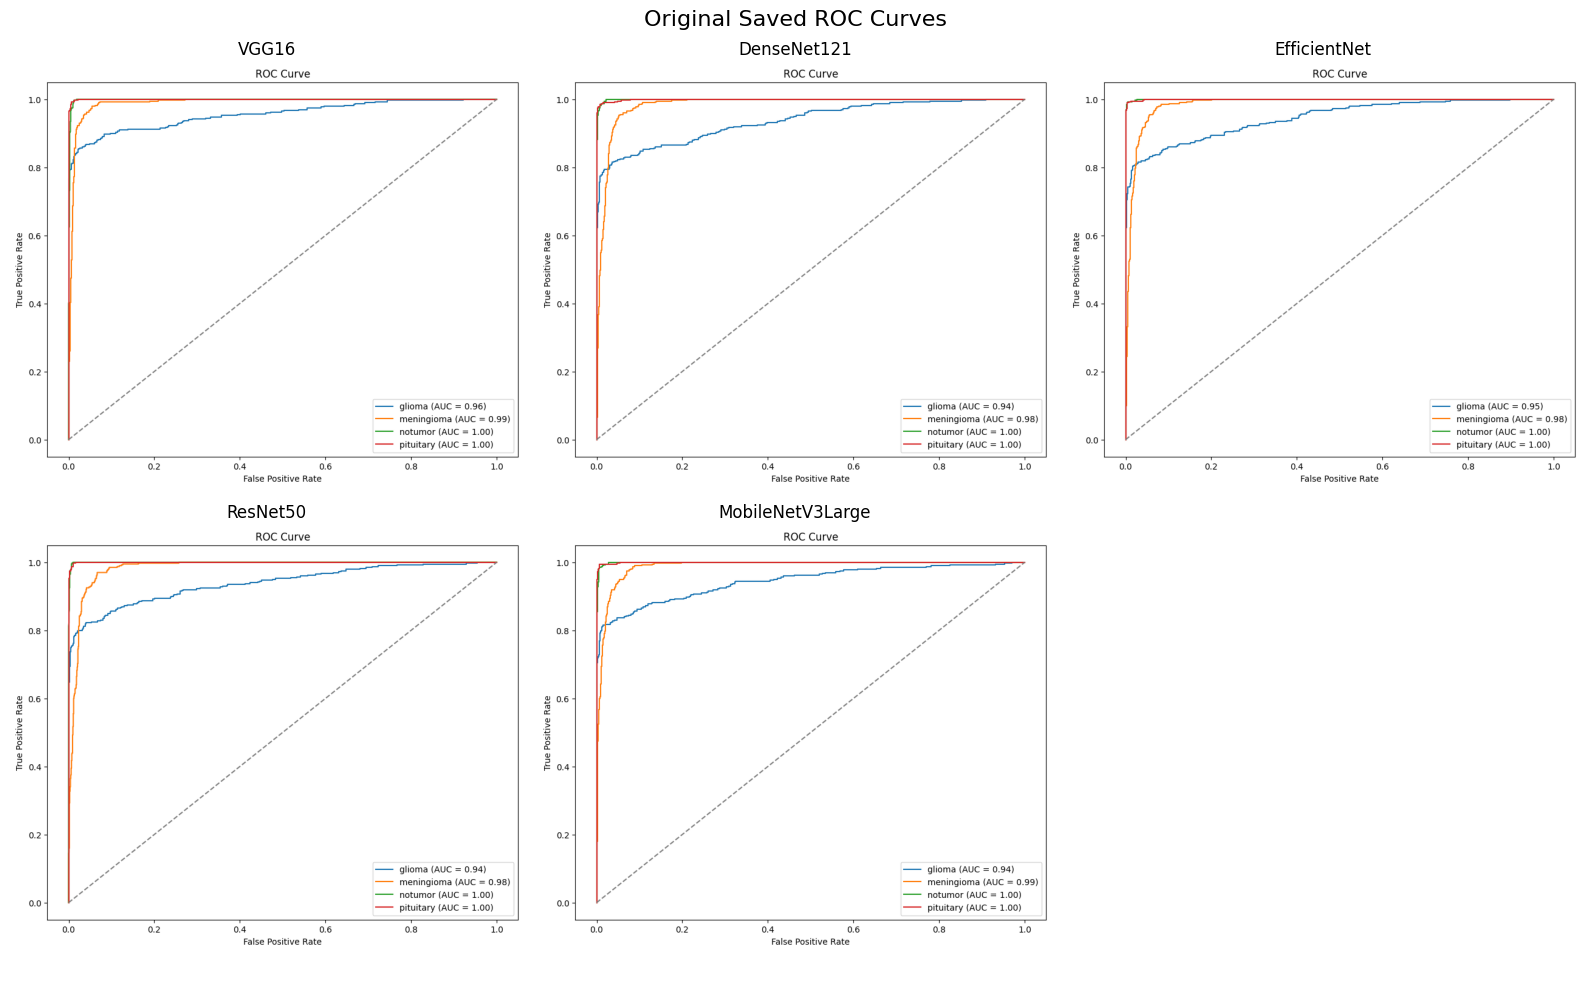

In [44]:
def calculate_roc_metrics(model_name, data):
    """Compute one-vs-rest class ROC/AUC plus micro and macro AUC."""
    y_bin=label_binarize(data["true_labels"],classes=np.arange(len(CLASS_NAMES)))
    prob=data["probabilities"]; result={"Model":model_name}; curves={}
    for i,cls in enumerate(CLASS_NAMES):
        fpr,tpr,_=roc_curve(y_bin[:,i],prob[:,i]); curves[cls]=(fpr,tpr); result[f"{cls} AUC"]=auc(fpr,tpr)
    fpr,tpr,_=roc_curve(y_bin.ravel(),prob.ravel()); curves["micro"]=(fpr,tpr)
    result["Micro AUC"]=auc(fpr,tpr)
    result["Macro AUC"]=roc_auc_score(y_bin,prob,average="macro",multi_class="ovr")
    return result,curves

auc_rows=[]; roc_curves={}
if fair_comparison:
    for model in MODEL_ORDER:
        row,curves=calculate_roc_metrics(model,prediction_data[model]); auc_rows.append(row); roc_curves[model]=curves
        plt.figure(figsize=(7,6))
        for cls in CLASS_NAMES:
            fpr,tpr=curves[cls]; plt.plot(fpr,tpr,label=f"{cls} (AUC = {row[f'{cls} AUC']:.3f})")
        plt.plot([0,1],[0,1],"--",color="gray"); plt.xlabel("False Positive Rate");plt.ylabel("True Positive Rate")
        plt.title(f"One-vs-Rest ROC — {model}");plt.legend();save_figure(f"roc_{model.lower()}.png");plt.show()
auc_df=pd.DataFrame(auc_rows)
if auc_df.empty:
    show_unavailable("Exact ROC/AUC values require class probabilities; showing the ROC curves saved during the original runs.")
    if reported_comparison: show_archived_training_plots(17, "Original Saved ROC Curves", "22_saved_roc_curves.png")
else:
    display(auc_df); auc_df.to_csv(OUTPUT_DIR/"auc_results.csv",index=False)
    plt.figure(figsize=(8,5)); heat=auc_df.set_index("Model").drop(columns="Micro AUC").reindex(MODEL_ORDER)
    sns.heatmap(heat,annot=True,fmt=".3f",vmin=0,vmax=1,cmap="YlGnBu");plt.title("AUC by Model and Class")
    save_figure("22_auc_heatmap.png");plt.show()
    plt.figure(figsize=(8,6))
    for model in MODEL_ORDER:
        fpr,tpr=roc_curves[model]["micro"];plt.plot(fpr,tpr,label=f"{model} (AUC={auc_df.set_index('Model').loc[model,'Micro AUC']:.3f})")
    plt.plot([0,1],[0,1],"--",color="gray");plt.legend();plt.xlabel("False Positive Rate");plt.ylabel("True Positive Rate")
    plt.title("Micro-Average ROC Curve — Model Comparison");save_figure("21_micro_roc_model_comparison.png");plt.show()

## 9. Efficiency and Fine-Tuning Comparison
### Parameters
### Training Time
### Model Size
### Performance vs Complexity

,Model,Total Parameters,Trainable Parameters,Non-Trainable Parameters,Total Layers,Trainable Layers,Frozen Layers,Model File Size MB,Model Path,Total Training Time Seconds,Seconds per Epoch,Accuracy,Macro F1
0,VGG16,14782916,7146628,7636288,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,111.006767,d:\Project-sem2\model_vgg16_v2.h5,49271.0,3284.733333,0.94,0.94
1,DenseNet121,7173316,948868,6224448,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,35.445038,d:\Project-sem2\model_densenet121.h5,8529.0,568.600000,0.92,0.92
2,EfficientNet,4219175,1650404,2568771,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,29.161163,d:\Project-sem2\model_efficientnet.h5,2088.0,298.285714,0.92,0.92
3,ResNet50,23858692,9185924,14672768,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,161.497452,d:\Project-sem2\model_resnet50.h5,13600.0,906.666667,0.92,0.92
4,MobileNetV3Large,3123716,1072244,2051472,Not available from saved experiment,Not available from saved experiment,Not available from saved experiment,20.770632,d:\Project-sem2\model_mobilenetv3large.keras,3.0,3.000000,0.93,0.92


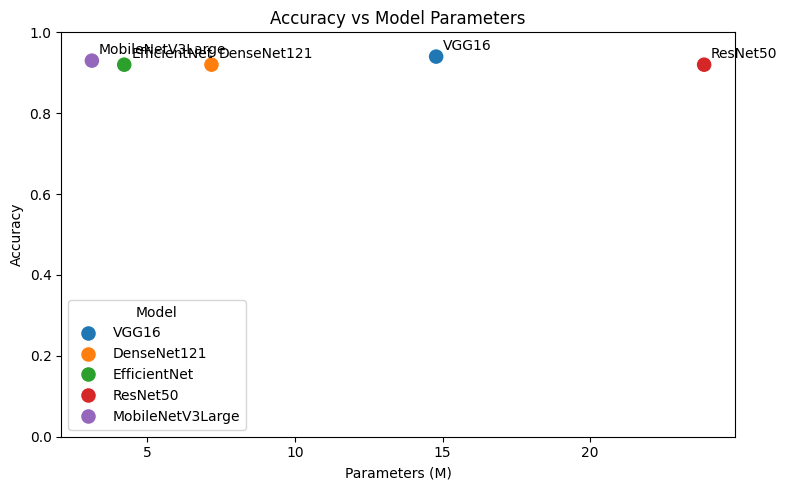

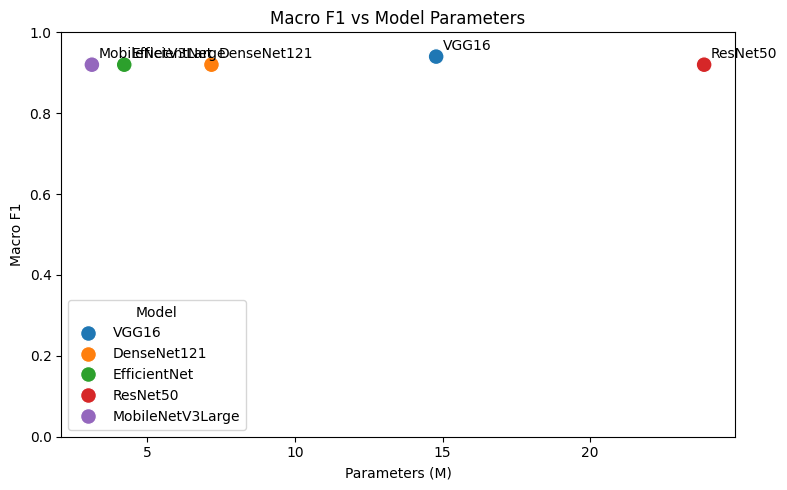

In [45]:
timing_df = training_history_df.groupby("Model", as_index=False).agg(
    **{
        "Total Training Time Seconds": ("Epoch Time Seconds", "sum"),
        "Seconds per Epoch": ("Epoch Time Seconds", "mean")
    }
)
efficiency_df=model_parameters_df.merge(timing_df,on="Model",how="left")
if not overall_metrics_df.empty:
    efficiency_df=efficiency_df.merge(overall_metrics_df[["Model","Accuracy","Macro F1"]],on="Model",how="left")
display(efficiency_df.fillna("Not available from saved experiment"))

if not overall_metrics_df.empty:
    for metric,filename in [("Accuracy","25_accuracy_vs_parameters.png"),("Macro F1","26_f1_vs_parameters.png")]:
        data=efficiency_df.dropna(subset=["Total Parameters",metric]).copy()
        data["Parameters (M)"]=data["Total Parameters"]/1e6
        plt.figure(figsize=(8,5));sns.scatterplot(data=data,x="Parameters (M)",y=metric,hue="Model",s=130)
        for _,r in data.iterrows():plt.annotate(r["Model"],(r["Parameters (M)"],r[metric]),xytext=(5,5),textcoords="offset points")
        plt.ylim(0,1);plt.title(f"{metric} vs Model Parameters");save_figure(filename);plt.show()

## 10. Overall Model Ranking
### Final Comparison Table
### Ranking
### Best Metrics
### Evidence-Based Findings

,Model,Accuracy Rank,F1 Rank,Recall Rank,Precision Rank,Mean Rank
0,VGG16,1.0,1.0,1.0,1.0,1.00
4,MobileNetV3Large,2.0,2.0,2.0,2.0,2.00
1,DenseNet121,3.0,2.0,3.0,2.0,2.50
2,EfficientNet,3.0,2.0,3.0,2.0,2.50
3,ResNet50,3.0,2.0,3.0,5.0,3.25


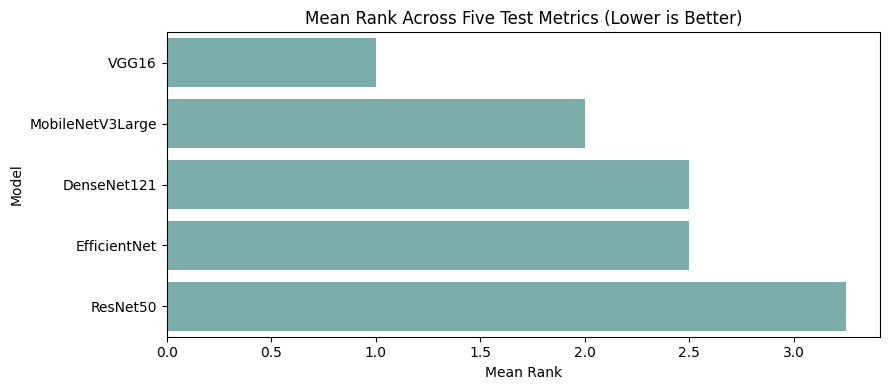

,Model,Total Parameters,Trainable Parameters,Model File Size MB,Batch Size,Actual Epochs,Best Training Accuracy,Final Training Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Macro AUC,Misclassified Images,Generalization Gap
0,VGG16,14782916,7146628,111.006767,20,15,0.9977,0.9977,0.94,0.94,0.94,0.94,NaN,NaN,0.0577
1,DenseNet121,7173316,948868,35.445038,20,15,0.9782,0.9782,0.92,0.93,0.92,0.92,NaN,NaN,0.0582
2,EfficientNet,4219175,1650404,29.161163,20,15,0.9655,0.9624,0.92,0.93,0.92,0.92,NaN,NaN,0.0424
3,ResNet50,23858692,9185924,161.497452,20,15,0.9987,0.9986,0.92,0.92,0.92,0.92,NaN,NaN,0.0786
4,MobileNetV3Large,3123716,1072244,20.770632,20,15,0.9784,0.9764,0.93,0.93,0.93,0.92,NaN,NaN,0.0464


Best Accuracy: VGG16
Best Macro F1: VGG16
Best Recall: VGG16
Best Precision: VGG16
Best AUC: Shown in original saved ROC curves; numeric AUC was not saved
Smallest Model: MobileNetV3Large
Fewest Parameters: MobileNetV3Large
Fewest Test Errors: Not numerically saved
Best overall model depends on whether priority is predictive performance, sensitivity, model size, or computational efficiency.


In [46]:
if overall_metrics_df.empty:
    model_ranking_df=pd.DataFrame()
    final_comparison_df=pd.DataFrame()
    show_unavailable("Ranking and a final winner require the fair-comparison metrics.")
else:
    ranks=overall_metrics_df.copy()
    model_ranking_df=pd.DataFrame({"Model":ranks["Model"]})
    for metric,label in [("Accuracy","Accuracy Rank"),("Macro F1","F1 Rank"),("Macro Recall","Recall Rank"),
                         ("Macro Precision","Precision Rank"),("Macro AUC","AUC Rank")]:
        if ranks[metric].notna().any(): model_ranking_df[label]=ranks[metric].rank(ascending=False,method="min")
    model_ranking_df["Mean Rank"]=model_ranking_df.drop(columns="Model").mean(axis=1)
    model_ranking_df=model_ranking_df.sort_values("Mean Rank")
    display(model_ranking_df);model_ranking_df.to_csv(OUTPUT_DIR/"model_ranking.csv",index=False)
    plt.figure(figsize=(9,4));sns.barplot(data=model_ranking_df,x="Mean Rank",y="Model",color="#72B7B2")
    plt.title("Mean Rank Across Five Test Metrics (Lower is Better)");save_figure("27_model_ranking.png");plt.show()

    final_comparison_df=(model_parameters_df.merge(model_config_df[["Model","Batch Size","Actual Epochs"]],on="Model")
        .merge(training_summary_df,on=["Model","Actual Epochs"],how="left").merge(overall_metrics_df,on="Model")
        .merge(confusion_summary_df[["Model","Incorrect Predictions"]],on="Model"))
    final_comparison_df["Generalization Gap"]=final_comparison_df["Final Training Accuracy"]-final_comparison_df["Accuracy"]
    final_comparison_df=final_comparison_df.rename(columns={"Accuracy":"Test Accuracy","Incorrect Predictions":"Misclassified Images"})
    keep=["Model","Total Parameters","Trainable Parameters","Model File Size MB","Batch Size","Actual Epochs",
          "Best Training Accuracy","Final Training Accuracy","Test Accuracy","Macro Precision","Macro Recall",
          "Macro F1","Macro AUC","Misclassified Images","Generalization Gap"]
    final_comparison_df=final_comparison_df[keep]
    display(final_comparison_df)
    final_comparison_df.to_csv(OUTPUT_DIR/"final_model_comparison.csv",index=False)
    print("Best Accuracy:",overall_metrics_df.loc[overall_metrics_df.Accuracy.idxmax(),"Model"])
    print("Best Macro F1:",overall_metrics_df.loc[overall_metrics_df["Macro F1"].idxmax(),"Model"])
    print("Best Recall:",overall_metrics_df.loc[overall_metrics_df["Macro Recall"].idxmax(),"Model"])
    print("Best Precision:",overall_metrics_df.loc[overall_metrics_df["Macro Precision"].idxmax(),"Model"])
    print("Best AUC:", overall_metrics_df.loc[overall_metrics_df["Macro AUC"].idxmax(),"Model"] if overall_metrics_df["Macro AUC"].notna().any() else "Shown in original saved ROC curves; numeric AUC was not saved")
    print("Smallest Model:",model_parameters_df.loc[model_parameters_df["Model File Size MB"].idxmin(),"Model"]
          if model_parameters_df["Model File Size MB"].notna().any() else "Not available from saved experiment")
    print("Fewest Parameters:",model_parameters_df.loc[model_parameters_df["Total Parameters"].idxmin(),"Model"])
    print("Fewest Test Errors:",confusion_summary_df.loc[confusion_summary_df["Incorrect Predictions"].idxmin(),"Model"] if confusion_summary_df["Incorrect Predictions"].notna().any() else "Not numerically saved")
    print("Best overall model depends on whether priority is predictive performance, sensitivity, model size, or computational efficiency.")

## 11. Error Analysis
### Misclassified MRI Examples
### Prediction Confidence

In [47]:
def show_prediction_examples(model_name, incorrect=True, n=8, seed=SEED):
    """Show reproducibly selected real test images with true/predicted class and confidence."""
    if not fair_comparison:return show_unavailable()
    data=prediction_data[model_name]; correct=data["true_labels"]==data["predicted_labels"]
    indices=np.where(~correct if incorrect else correct)[0]
    if not len(indices):return print("No matching examples.")
    rng=np.random.default_rng(seed);chosen=rng.choice(indices,size=min(n,len(indices)),replace=False)
    fig,axes=plt.subplots(2,4,figsize=(14,7));axes=axes.flat
    for ax in axes:ax.axis("off")
    for ax,i in zip(axes,chosen):
        with Image.open(data["image_paths"][i]) as image:ax.imshow(image.convert("RGB"))
        true=CLASS_NAMES[int(data["true_labels"][i])];pred=CLASS_NAMES[int(data["predicted_labels"][i])]
        conf=float(data["probabilities"][i].max())
        ax.set_title(f"True: {true}\nPredicted: {pred}\nConfidence: {conf:.2%}",fontsize=9)
    fig.suptitle(f"{model_name} — {'Misclassified' if incorrect else 'Correct'} Examples");plt.tight_layout();plt.show()

if fair_comparison:
    for model in MODEL_ORDER:show_prediction_examples(model,incorrect=True)
    confidence_rows=[]
    for model in MODEL_ORDER:
        d=prediction_data[model];correct=d["true_labels"]==d["predicted_labels"]
        confidence_rows.extend({"Model":model,"Confidence":float(c),"Outcome":"Correct" if ok else "Incorrect"}
                               for c,ok in zip(d["probabilities"].max(axis=1),correct))
    confidence_df=pd.DataFrame(confidence_rows)
    g=sns.displot(data=confidence_df,x="Confidence",hue="Outcome",col="Model",col_wrap=2,
                  kind="hist",stat="density",common_norm=False,element="step",height=3.2)
    g.fig.suptitle("Prediction Confidence — Correct vs Incorrect",y=1.02)
    print("Softmax confidence is not a calibrated clinical probability.")
else:show_unavailable("Misclassified examples and confidence distributions require aligned probability predictions.")

Misclassified examples and confidence distributions require aligned probability predictions.


## 12. Conclusion

In [48]:
def evidence_based_conclusion():
    """Generate conclusions only from fair, calculated results."""
    if overall_metrics_df.empty:
        print("A comparative conclusion is not available from saved experiment because the dataset/model files or valid aligned probability caches are absent.")
        print("The notebook deliberately does not declare a winner from rounded, separately embedded reports.")
        return
    hardest=per_class_metrics_df.groupby("Class")["F1"].mean().idxmin()
    smallest_gap=final_comparison_df.loc[final_comparison_df["Generalization Gap"].abs().idxmin(),"Model"]
    fewest=confusion_summary_df.loc[confusion_summary_df["Incorrect Predictions"].idxmin(),"Model"] if confusion_summary_df["Incorrect Predictions"].notna().any() else "Not numerically saved"
    answers=[
        ("Highest test accuracy",overall_metrics_df.loc[overall_metrics_df.Accuracy.idxmax(),"Model"]),
        ("Highest macro F1",overall_metrics_df.loc[overall_metrics_df["Macro F1"].idxmax(),"Model"]),
        ("Highest macro recall",overall_metrics_df.loc[overall_metrics_df["Macro Recall"].idxmax(),"Model"]),
        ("Highest macro precision",overall_metrics_df.loc[overall_metrics_df["Macro Precision"].idxmax(),"Model"]),
        ("Highest macro AUC",overall_metrics_df.loc[overall_metrics_df["Macro AUC"].idxmax(),"Model"] if overall_metrics_df["Macro AUC"].notna().any() else "Numeric value not saved"),
        ("Fewest parameters",model_parameters_df.loc[model_parameters_df["Total Parameters"].idxmin(),"Model"]),
        ("Smallest absolute training–test gap",smallest_gap),("Hardest class by mean F1",hardest),
        ("Fewest held-out errors",fewest)]
    for label,value in answers:print(f"{label}: {value}")
    print("\nThese models were compared only on this held-out dataset; no clinical-diagnostic claim is made.")
evidence_based_conclusion()

print("\nFinal artifact status")
print("- Models discovered:", [m for m,p in artifacts["notebooks"].items() if p])
print("- Dataset discovered:", str(DATASET_ROOT) if DATASET_ROOT else "Not available from saved experiment")
print("- Trained model files discovered:", [str(p) for p in artifacts["models"]] or "None")
print("- Metrics recoverable from notebook outputs: training loss/accuracy, epoch timing, parameter summaries, rounded classification reports")
print("- Metrics requiring aligned inference/cache: exact overall/per-class metrics, confusion matrices, ROC/AUC, confidence and image-level errors")
print("- Missing artifacts:", "dataset and/or saved models/probability caches" if not fair_comparison else "None required for comparison")

Highest test accuracy: VGG16
Highest macro F1: VGG16
Highest macro recall: VGG16
Highest macro precision: VGG16
Highest macro AUC: Numeric value not saved
Fewest parameters: MobileNetV3Large
Smallest absolute training–test gap: EfficientNet
Hardest class by mean F1: glioma
Fewest held-out errors: Not numerically saved

These models were compared only on this held-out dataset; no clinical-diagnostic claim is made.

Final artifact status
- Models discovered: ['VGG16', 'DenseNet121', 'EfficientNet', 'ResNet50', 'MobileNetV3Large']
- Dataset discovered: d:\Project-sem2\Dataset\archive
- Trained model files discovered: ['d:\\Project-sem2\\model_densenet121.h5', 'd:\\Project-sem2\\model_efficientnet.h5', 'd:\\Project-sem2\\model_mobilenetv3large.keras', 'd:\\Project-sem2\\model_resnet50.h5', 'd:\\Project-sem2\\model_vgg16_v2.h5']
- Metrics recoverable from notebook outputs: training loss/accuracy, epoch timing, parameter summaries, rounded classification reports
- Metrics requiring aligned i

### Interpretation boundary

Results describe performance on the discovered held-out dataset. They do not demonstrate clinical validity and must not be interpreted as patient diagnosis. Where artifacts are absent, the notebook reports **“Not available from saved experiment”** rather than creating synthetic values.